=== STARTING THE BULLETPROOF 4-MODEL ABLATION PIPELINE ===

Fitting Baseline Models with Robust Error Catching...

Extracting CLOUD (MCMC) Parameters across restricted domains...
 -> Processing 4. CLOUD...

Aggregating Results...
Generating Final Publication Visuals in PNG, SVG, and PDF formats...

TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN RMSE)
Model        1. Naive LMM  2. LPMM Approximation  3. Univariate CAR(1)  4. CLOUD
Target                                                                          
Total Score         2.552                  2.465                 4.106     1.410
Bulbar              0.841                  2.313                 1.013     0.685
Fine_Motor          0.982                  2.035                 1.259     0.502
Gross_Motor         0.971                  2.172                 1.297     0.974
Respiratory         0.988                  1.478                 1.220     0.490

TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN MAE)
M

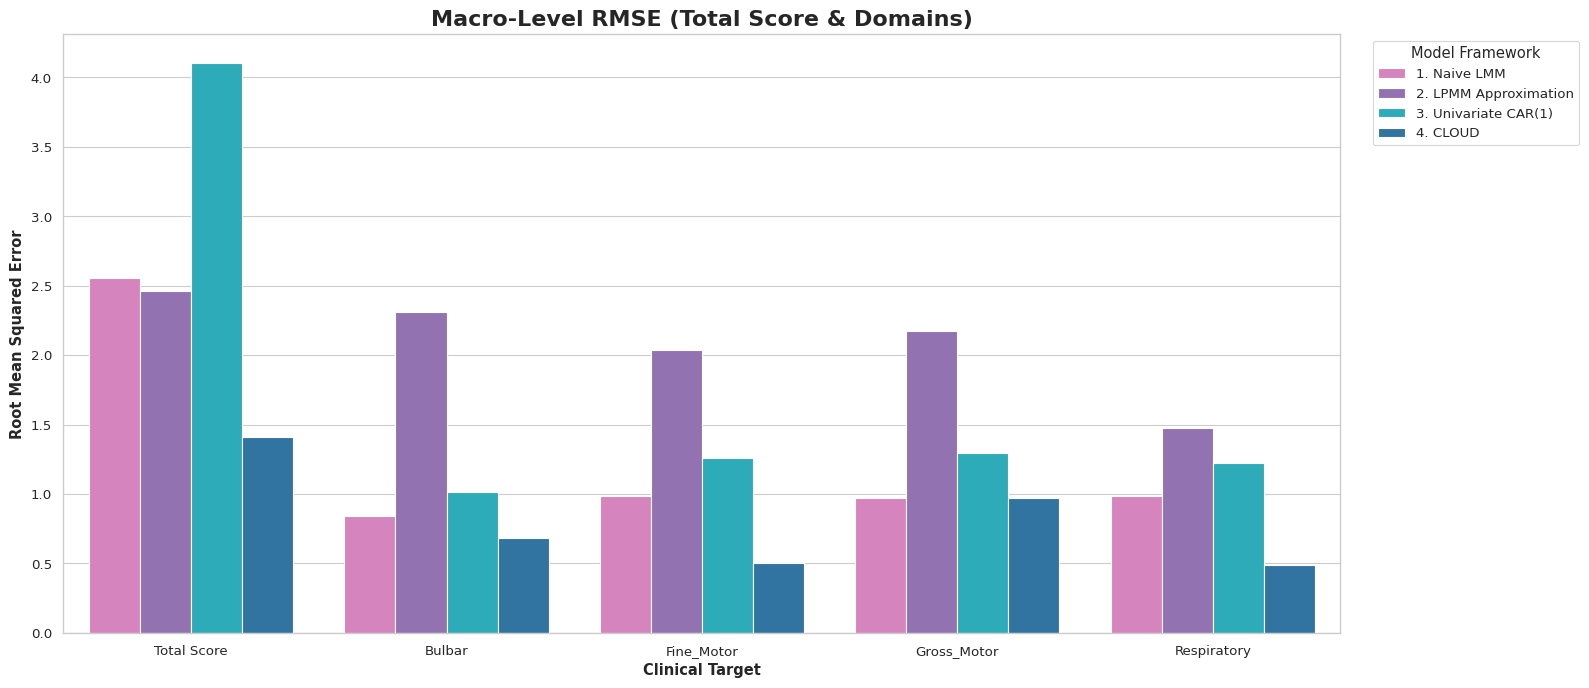

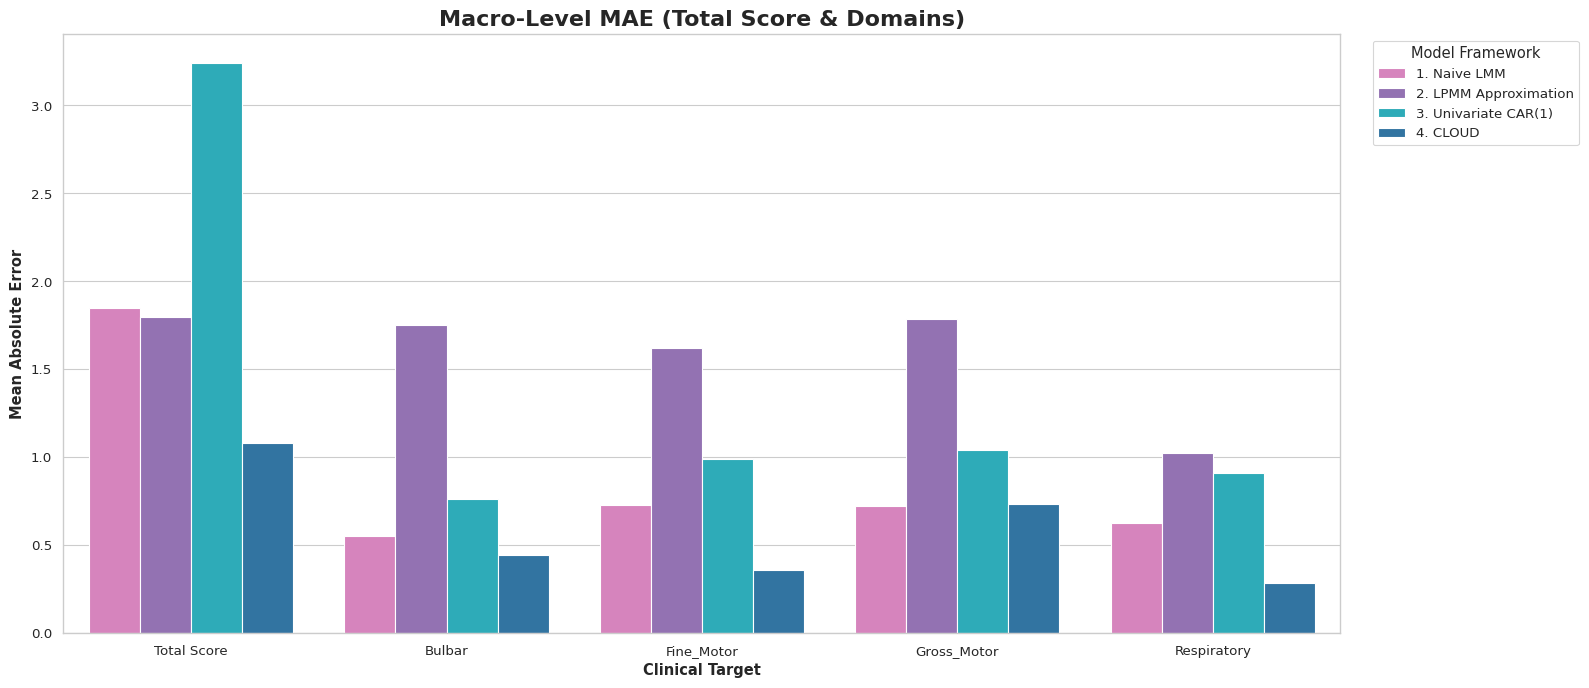

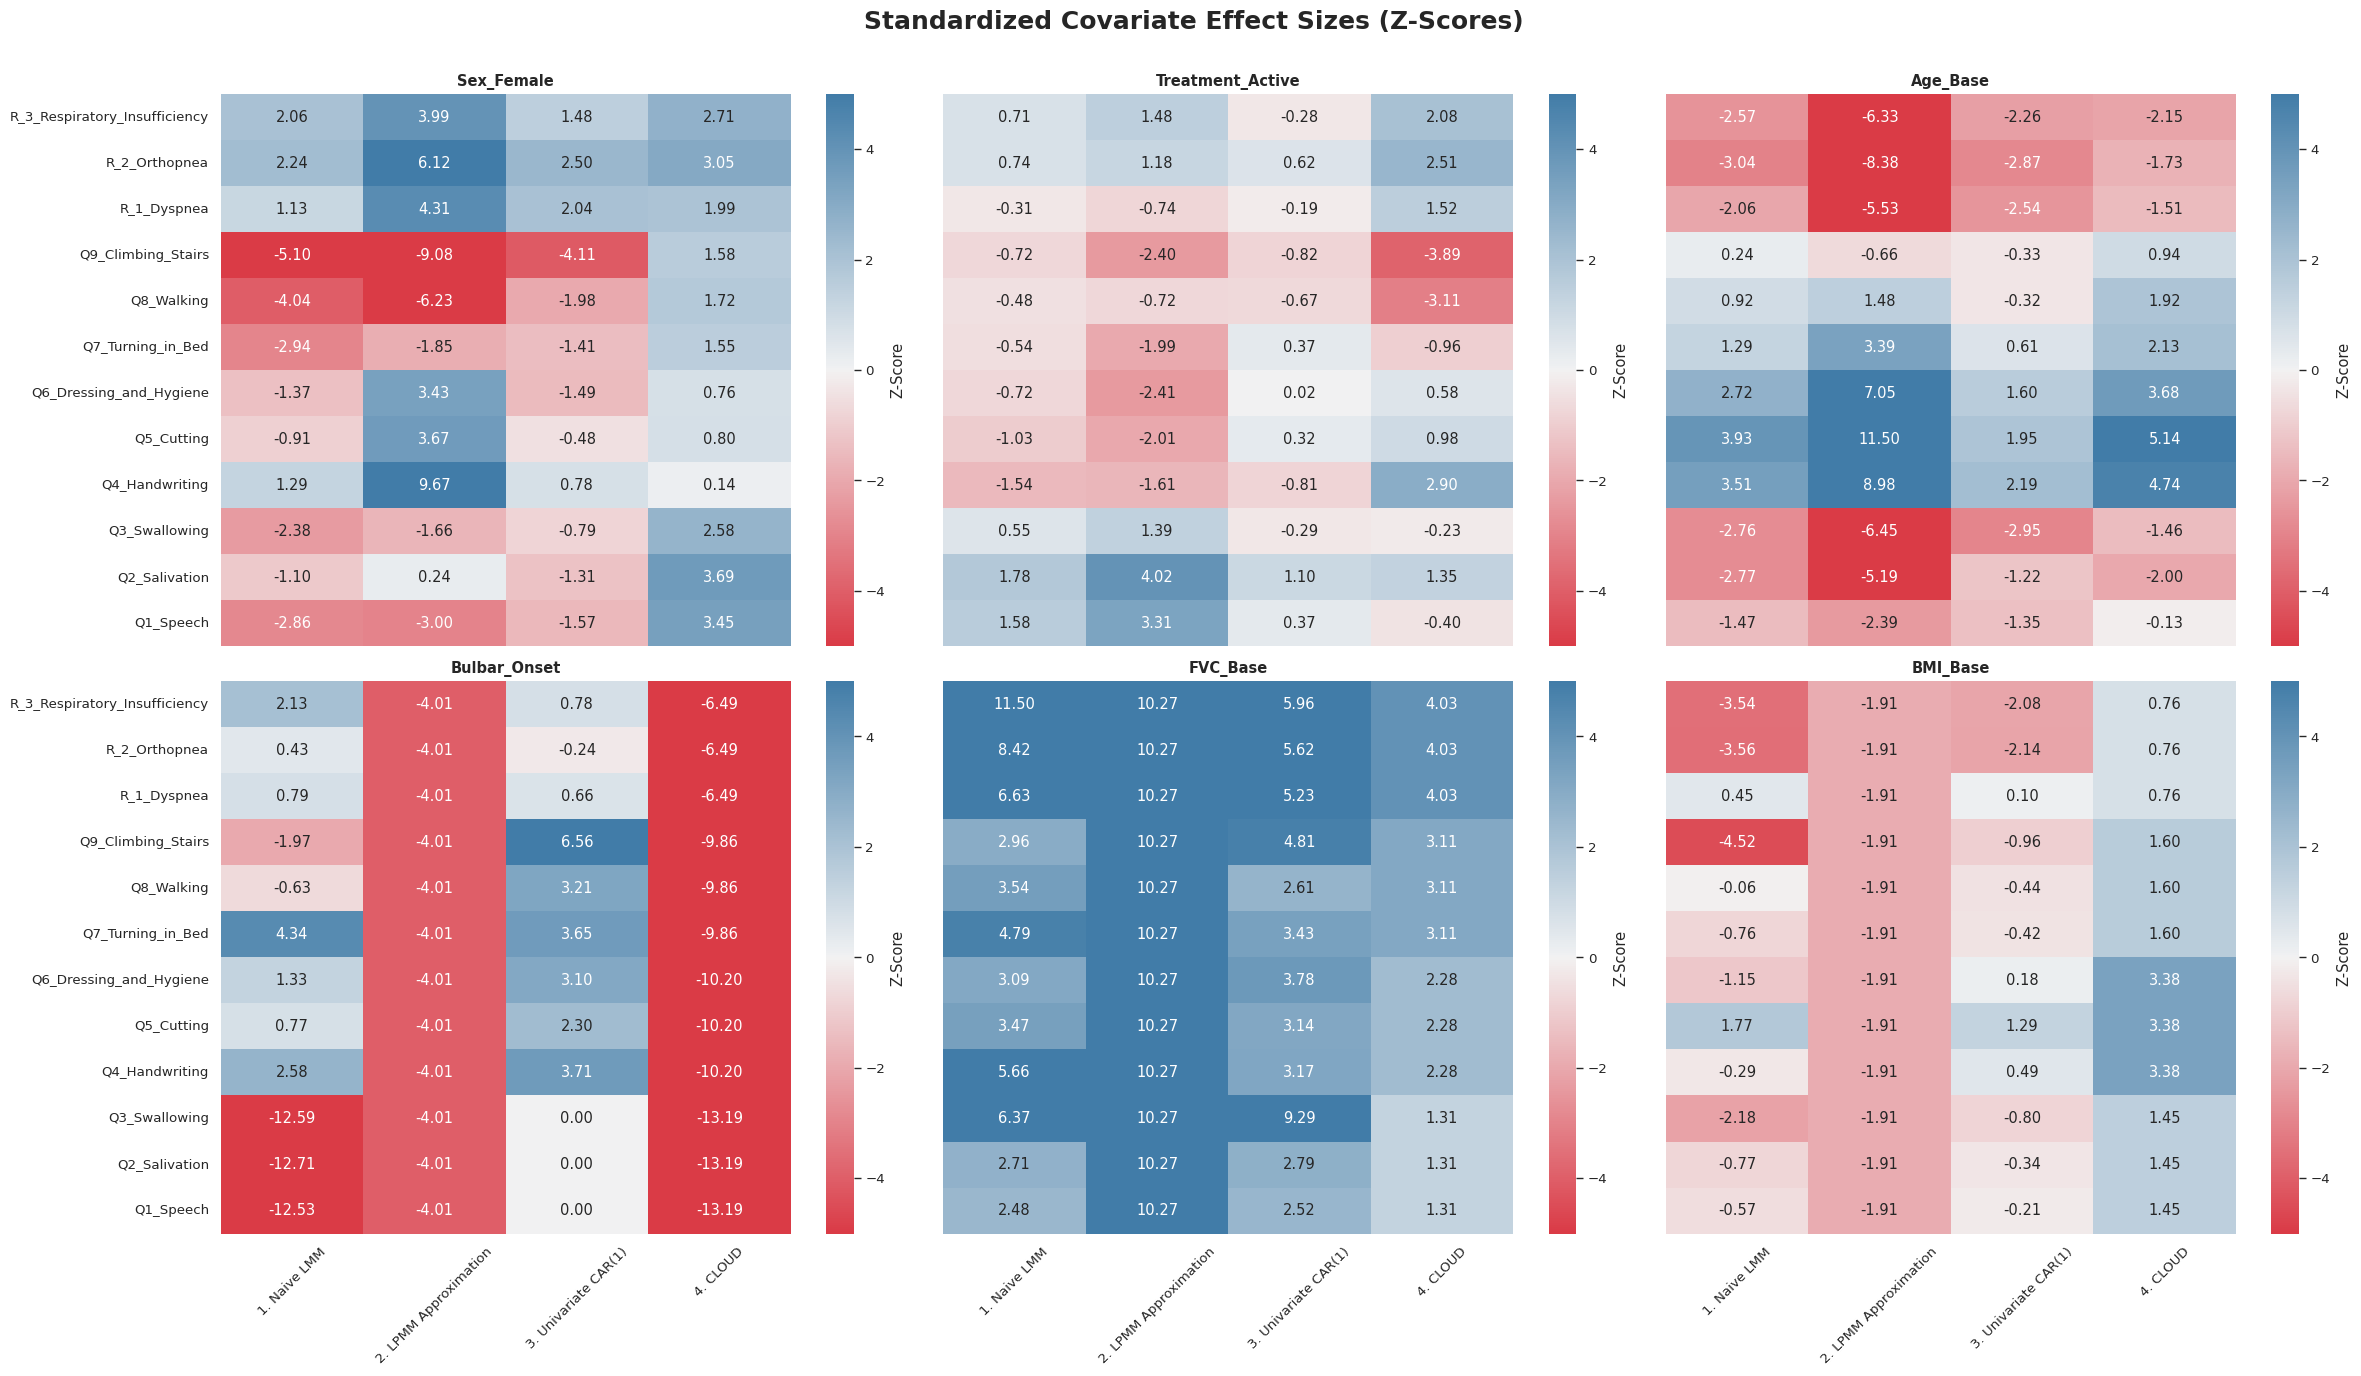

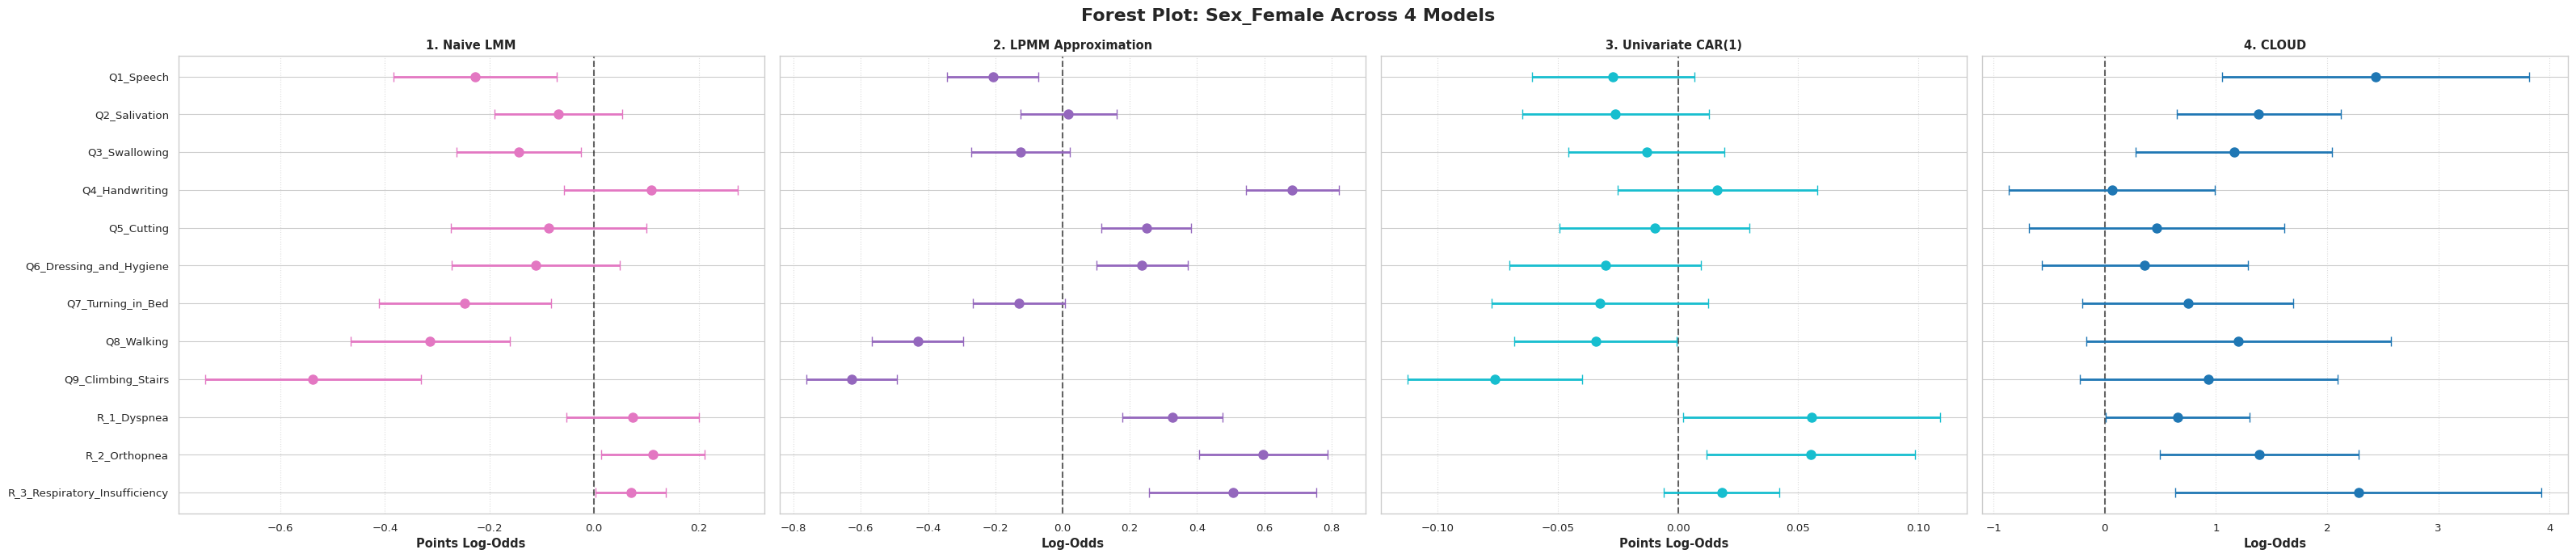

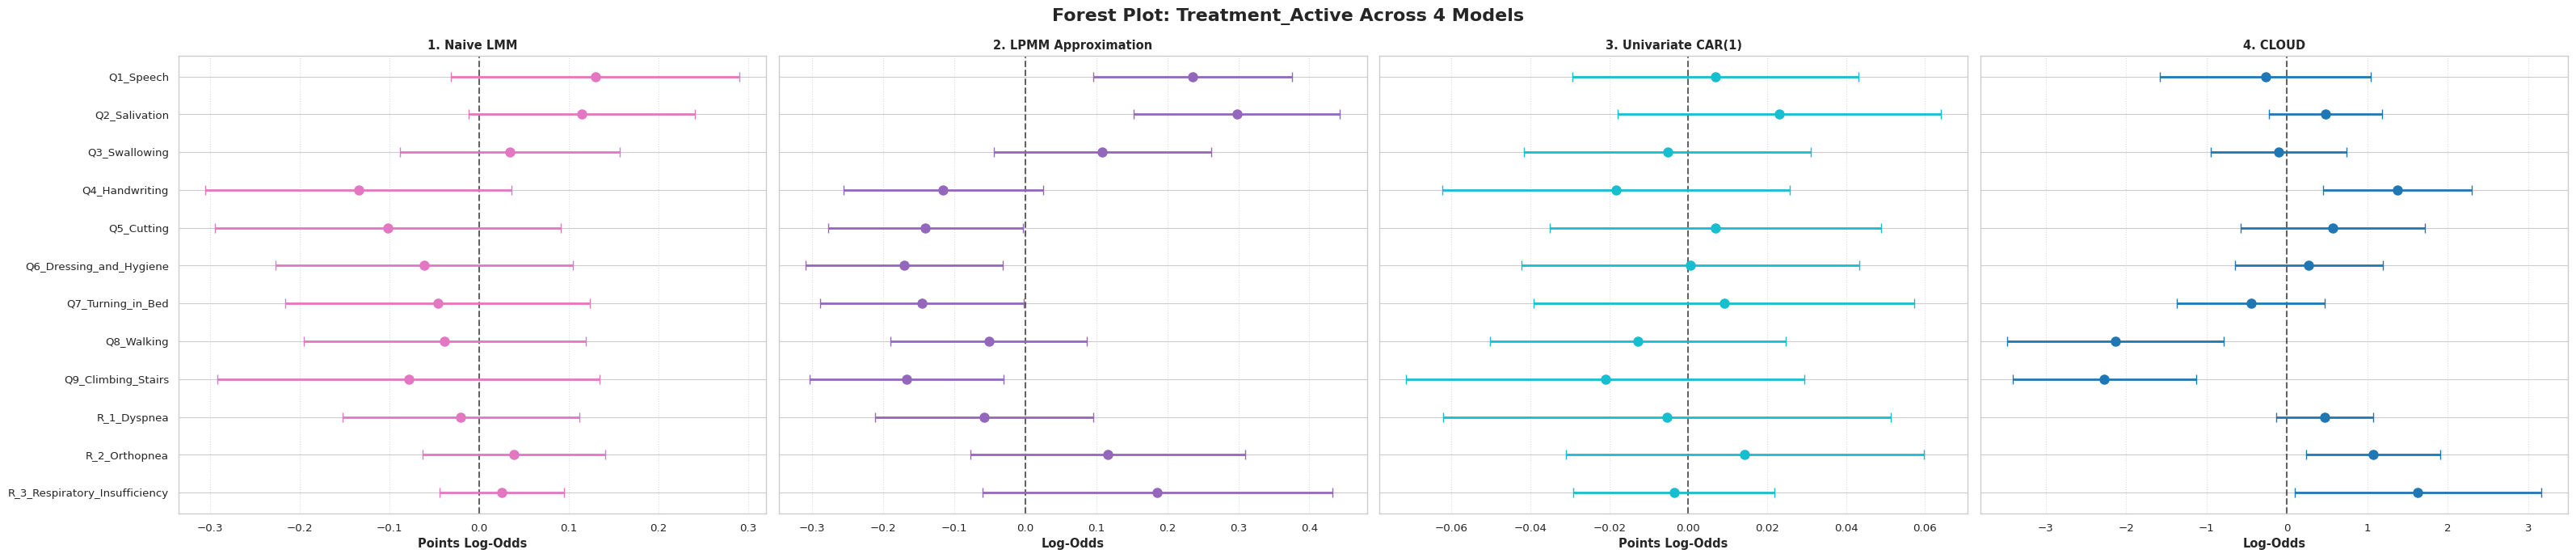

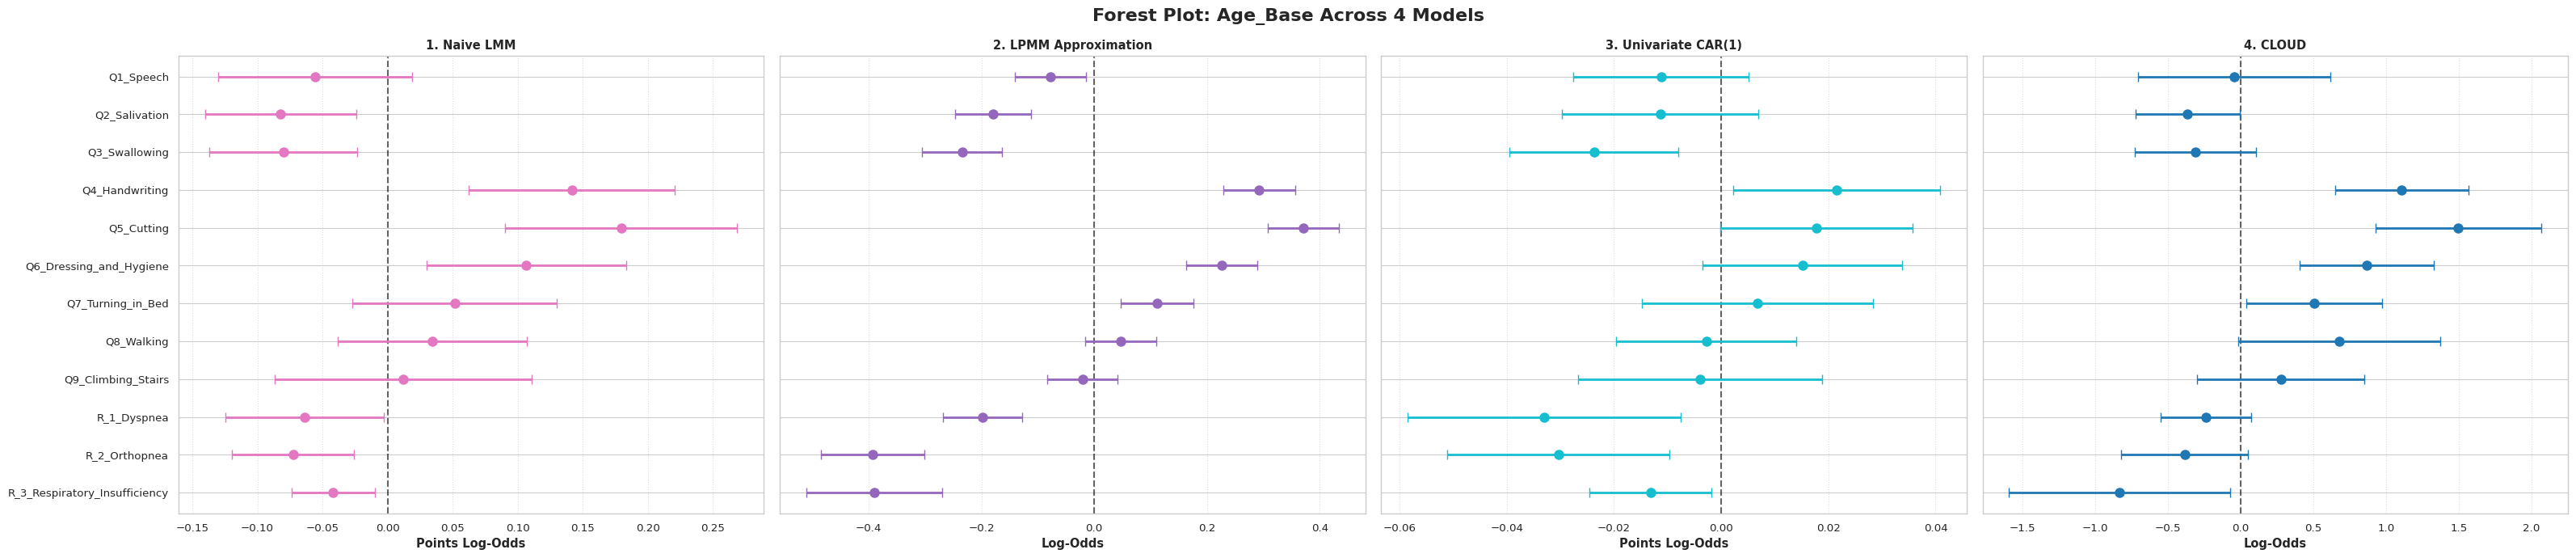

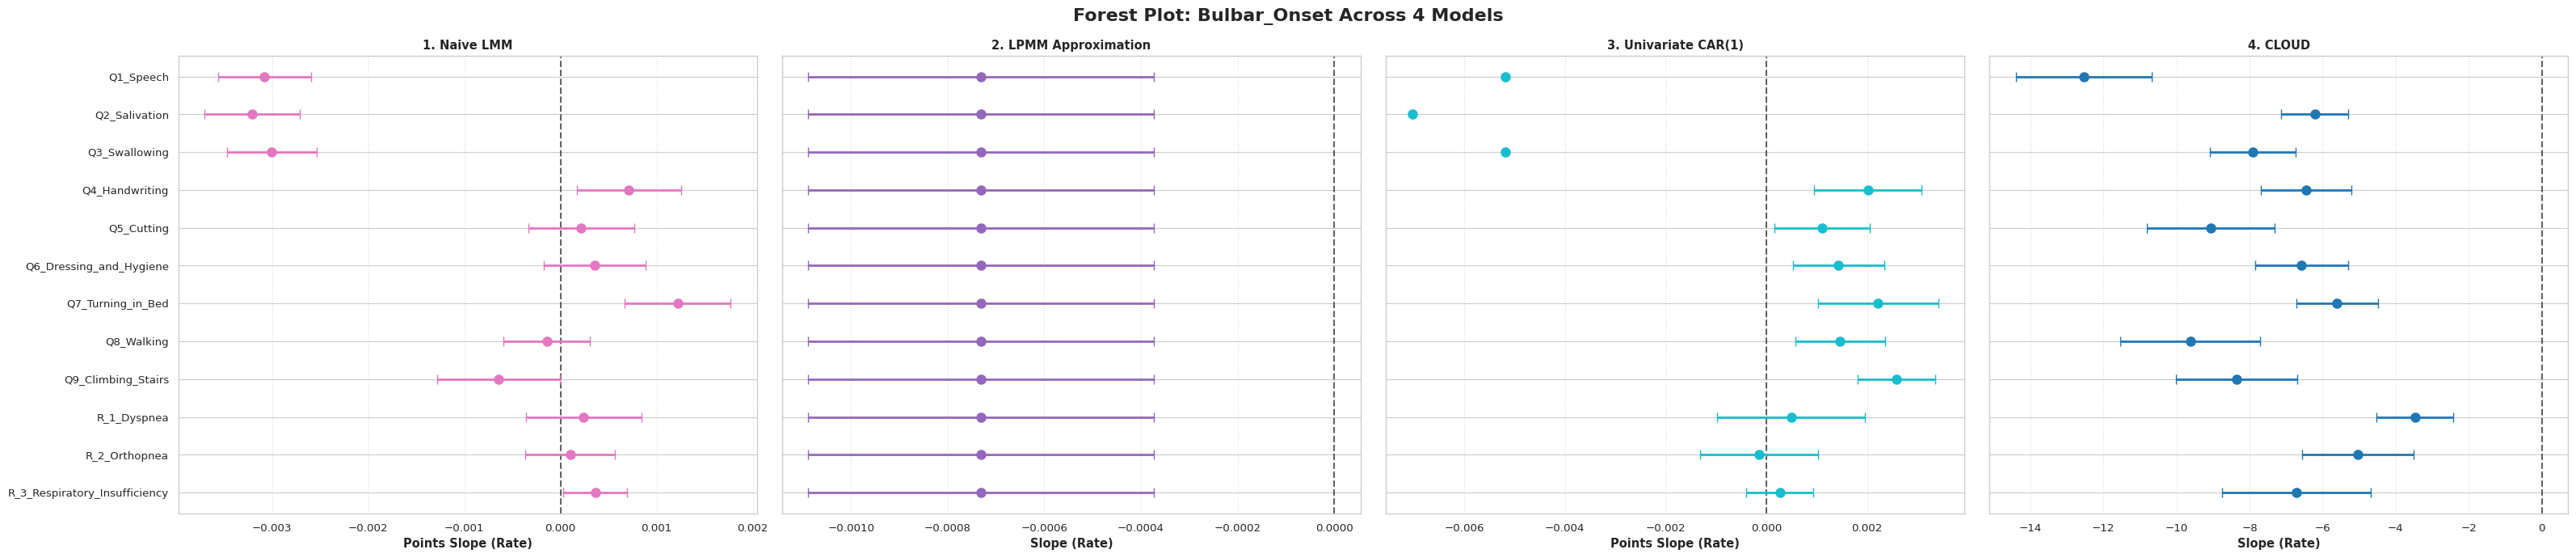

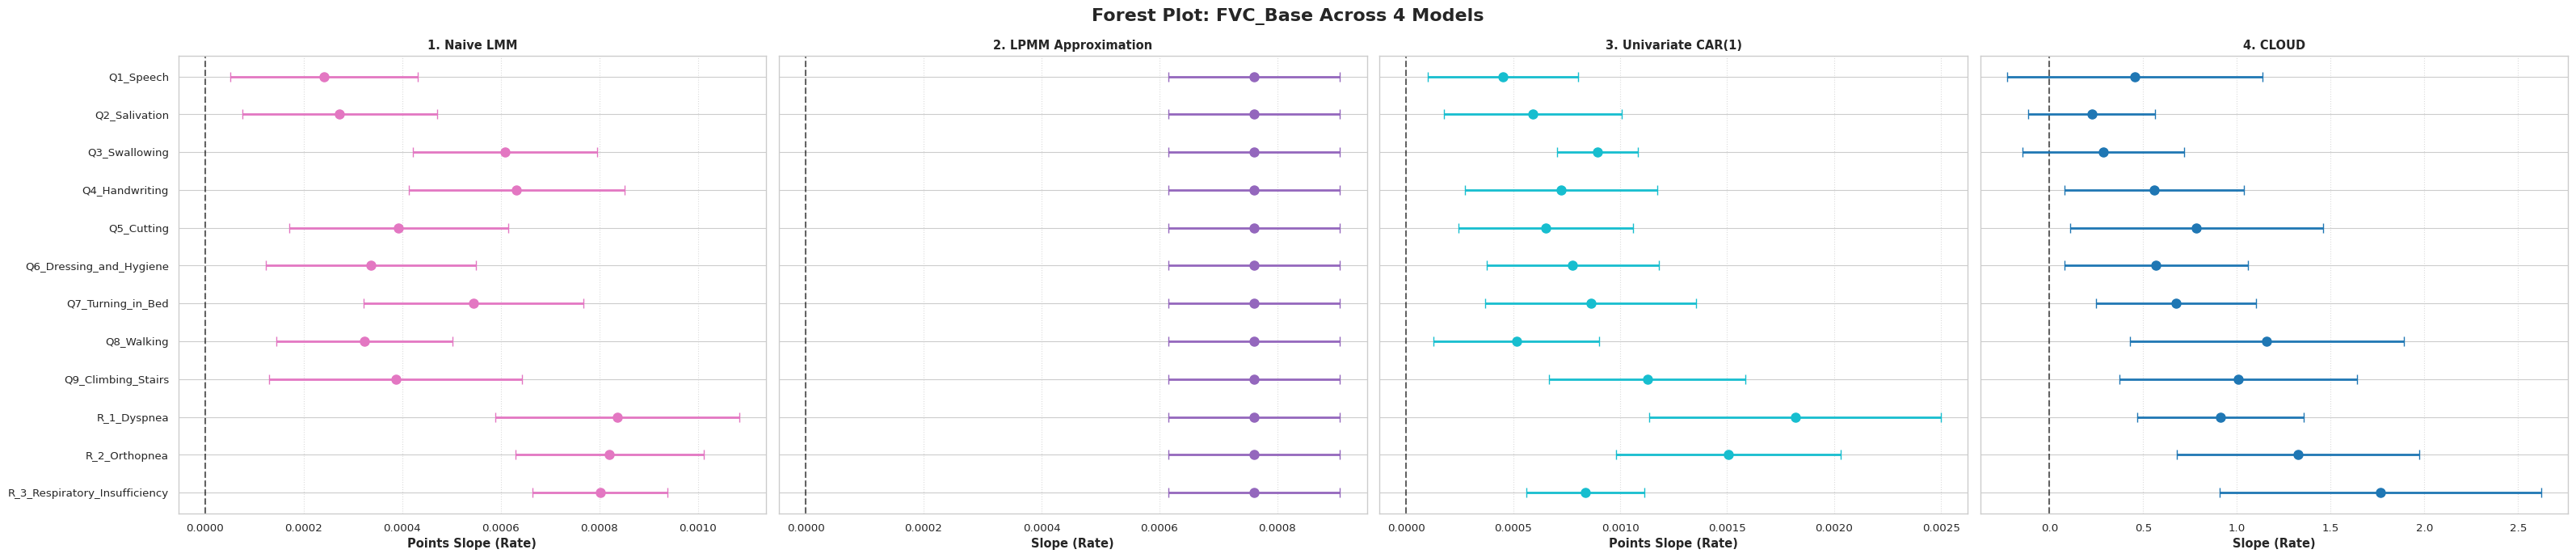

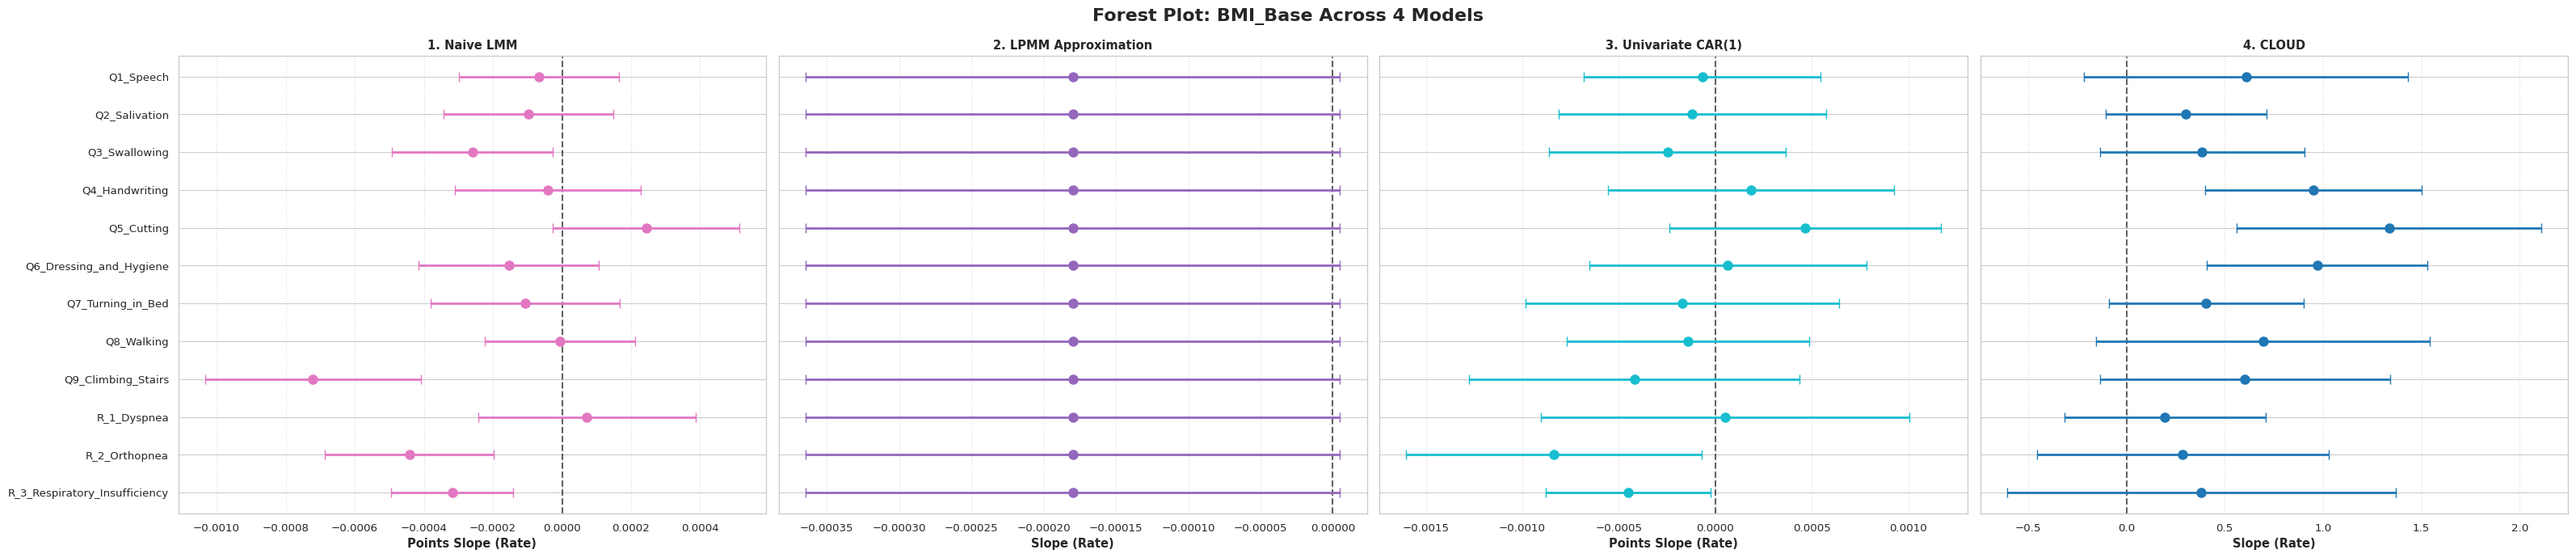

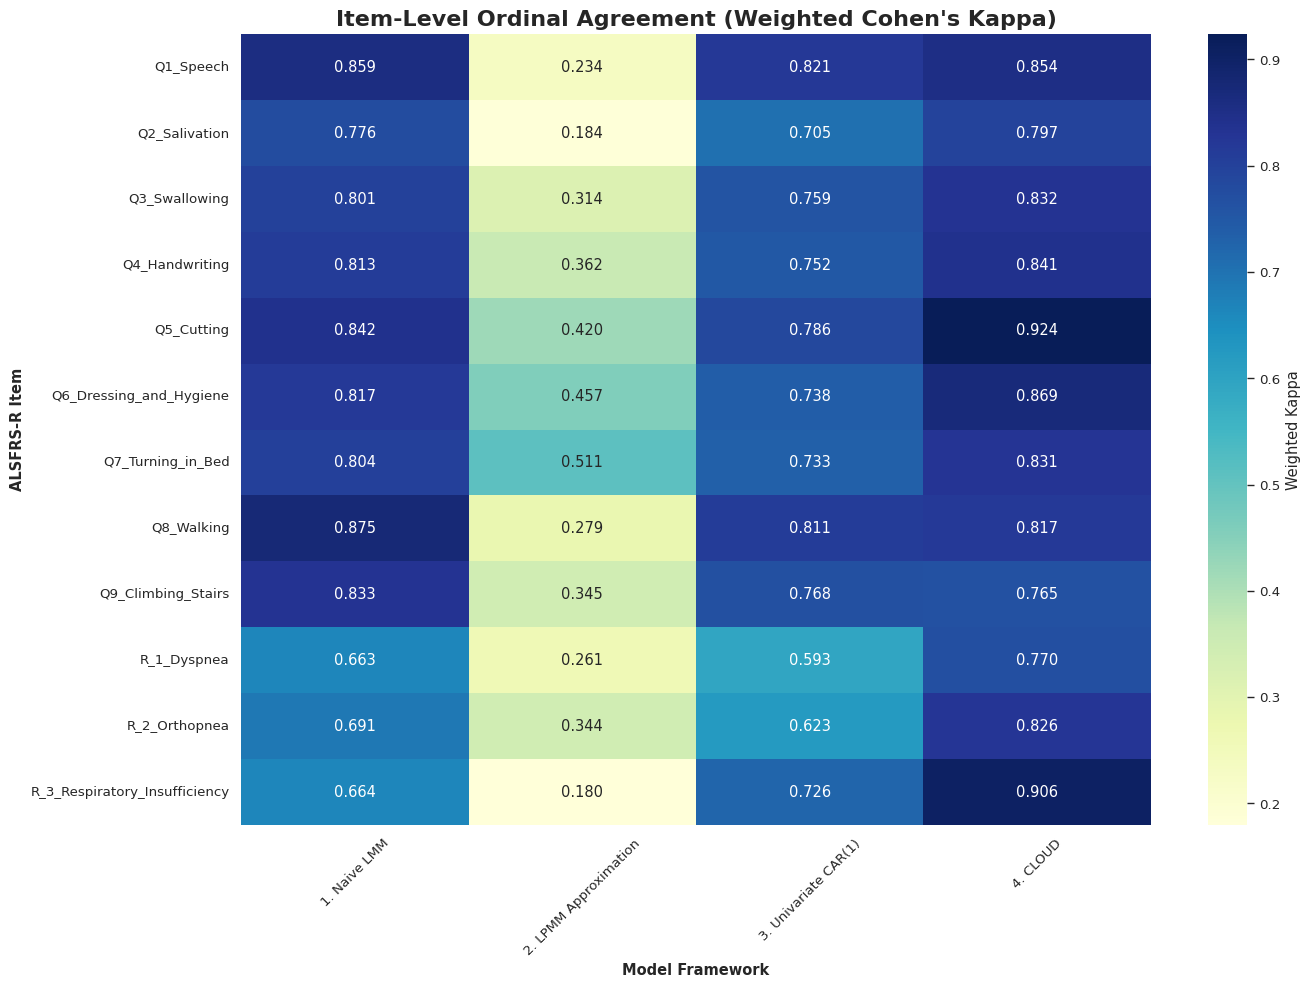

In [34]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import mean_squared_error, mean_absolute_error, cohen_kappa_score
from scipy.special import expit
from girth import grm_mml
from sklearn.decomposition import FactorAnalysis
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# ==========================================
# 0. CONFIGURATION & FEATURE ENGINEERING
# ==========================================
print("=== STARTING THE BULLETPROOF 4-MODEL ABLATION PIPELINE ===")

DATA_FILE = "proact_preprocessed_S1.csv"         
MCMC_FILES = {
    '4. CLOUD': "../raw_results/results_S1_dahlou_ncp_cov_run1.csv"
}

df = pd.read_csv(DATA_FILE)

mcmc_dfs = {}
for name, path in MCMC_FILES.items():
    try:
        mcmc_dfs[name] = pd.read_csv(path)
    except Exception as e:
        print(f"[WARNING] Could not load {path}: {e}")

domains = {
    'Bulbar': ['Q1_Speech', 'Q2_Salivation', 'Q3_Swallowing'],
    'Fine_Motor': ['Q4_Handwriting', 'Q5_Cutting', 'Q6_Dressing_and_Hygiene'],
    'Gross_Motor': ['Q7_Turning_in_Bed', 'Q8_Walking', 'Q9_Climbing_Stairs'],
    'Respiratory': ['R_1_Dyspnea', 'R_2_Orthopnea', 'R_3_Respiratory_Insufficiency']
}
all_items = [item for sublist in domains.values() for item in sublist]
scenarios = {'Total Score': all_items, **domains}

meas_covariates = ['Sex_Female', 'Treatment_Active', 'Age_Base']
dyn_covariates = ['Bulbar_Onset', 'FVC_Base', 'BMI_Base']
all_covariates = meas_covariates + dyn_covariates

# Prepare aggregations and lags
df['Total Score'] = df[all_items].sum(axis=1)
for dom, items in domains.items():
    df[dom] = df[items].sum(axis=1)

df = df.sort_values(by=['subject_id', 'ALSFRS_Delta'])
df['Delta_Lag'] = df.groupby('subject_id')['ALSFRS_Delta'].shift(1)
df['Time_Gap'] = df['ALSFRS_Delta'] - df['Delta_Lag']

# FEATURE ENGINEERING: Time Interactions for Dynamic Covariates
for c in dyn_covariates:
    df[f'{c}_x_Time'] = df[c] * df['ALSFRS_Delta']
    df[f'{c}_x_Gap'] = df[c] * df['Time_Gap']

meas_str = " + ".join(meas_covariates)
dyn_time_str = " + ".join([f"{c}_x_Time" for c in dyn_covariates])
dyn_gap_str = " + ".join([f"{c}_x_Gap" for c in dyn_covariates])

df['Total_Z'] = (df['Total Score'] - df['Total Score'].mean()) / df['Total Score'].std()

metrics_results = []
covariate_results = []

# --- SAFE EXTRACTION HELPERS ---
def get_z(m, term):
    try: 
        v = m.tvalues[term]
        return 0.0 if pd.isna(v) else v
    except: return 0.0

def get_se(m, term):
    try: 
        v = m.bse[term]
        return 0.0 if pd.isna(v) else v
    except: return 0.0

def get_est(m, term):
    try: 
        v = m.params[term]
        return 0.0 if pd.isna(v) else v
    except: return 0.0

def add_metrics(model_name, level, target, actual, expected):
    # Mask NaNs so restricted models (like 3D) don't crash
    mask = ~np.isnan(expected) & ~np.isnan(actual)
    if not np.any(mask): return
    actual_m, expected_m = actual[mask], expected[mask]
    
    rmse = np.sqrt(mean_squared_error(actual_m, expected_m))
    mae = mean_absolute_error(actual_m, expected_m)
    if level == 'Item':
        pred_cat = np.clip(np.round(expected_m), 0, 4)
        exact = np.mean(pred_cat == actual_m) * 100
        kappa = cohen_kappa_score(actual_m, pred_cat, weights='linear')
    else:
        exact, kappa = np.nan, np.nan
        
    metrics_results.append({
        'Model': model_name, 'Level': level, 'Target': target,
        'RMSE': rmse, 'MAE': mae, 'Exact_Match_%': exact, 'Weighted_Kappa': kappa
    })

def get_irt_exp(theta, disc, diffs):
    p_ge = [expit(disc * (theta - th)) for th in diffs]
    p4, p3, p2, p1, p0 = p_ge[3], p_ge[2]-p_ge[3], p_ge[1]-p_ge[2], p_ge[0]-p_ge[1], 1.0-p_ge[0]
    return (0*p0) + (1*p1) + (2*p2) + (3*p3) + (4*p4)

# ==========================================
# 1. BASELINES 1-3 & 5: FIT & PREDICT
# ==========================================
print("\nFitting Baseline Models with Robust Error Catching...")

lpmm_dyn = smf.mixedlm(f"Total_Z ~ ALSFRS_Delta + {dyn_time_str}", data=df.dropna(subset=['Total_Z'] + [f"{c}_x_Time" for c in dyn_covariates]), groups=df.dropna(subset=['Total_Z'] + [f"{c}_x_Time" for c in dyn_covariates])["subject_id"]).fit(reml=False, disp=False)
df['Lambda_it'] = lpmm_dyn.fittedvalues
lpmm_dyn_z = {c: get_z(lpmm_dyn, f'{c}_x_Time') for c in dyn_covariates}
lpmm_dyn_se = {c: get_se(lpmm_dyn, f'{c}_x_Time') for c in dyn_covariates}
lpmm_dyn_est = {c: get_est(lpmm_dyn, f'{c}_x_Time') for c in dyn_covariates}

for item in all_items:
    df['Item_Lag'] = df.groupby('subject_id')[item].shift(1) 
    req_cols = [item, 'Lambda_it', 'Item_Lag', 'Time_Gap', 'ALSFRS_Delta'] + meas_covariates + [f"{c}_x_Time" for c in dyn_covariates] + [f"{c}_x_Gap" for c in dyn_covariates]
    df_clean = df.dropna(subset=req_cols).copy()
    df_clean['Item_Cat'] = pd.Categorical(df_clean[item].astype(int), ordered=True)
    
    # --- Model 1: Naive LMM ---
    m1 = None
    try: 
        m1 = smf.mixedlm(f"{item} ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}", data=df_clean, groups=df_clean["subject_id"]).fit(reml=False, disp=False)
    except Exception as e: 
        try: m1 = smf.ols(f"{item} ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}", data=df_clean).fit()
        except Exception: pass

    if m1 is not None:
        add_metrics('1. Naive LMM', 'Item', item, df_clean[item].values, np.clip(m1.fittedvalues.values, 0, 4))
        for c in meas_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '1. Naive LMM', 'Z_Score': get_z(m1, c), 'SE': get_se(m1, c), 'Est': get_est(m1, c)})
        for c in dyn_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '1. Naive LMM', 'Z_Score': get_z(m1, f'{c}_x_Time'), 'SE': get_se(m1, f'{c}_x_Time'), 'Est': get_est(m1, f'{c}_x_Time')})

    # --- Model 2: LPMM Approximation ---
    try:
        exog_m2 = ['Lambda_it'] + meas_covariates
        m2 = OrderedModel(df_clean['Item_Cat'], df_clean[exog_m2], distr='logit').fit(method='bfgs', disp=False)
        add_metrics('2. LPMM Approximation', 'Item', item, df_clean[item].values, (m2.predict(df_clean[exog_m2]).values * np.arange(5)).sum(axis=1))
        for c in meas_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '2. LPMM Approximation', 'Z_Score': get_z(m2, c), 'SE': get_se(m2, c), 'Est': get_est(m2, c)})
        for c in dyn_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '2. LPMM Approximation', 'Z_Score': lpmm_dyn_z[c], 'SE': lpmm_dyn_se[c], 'Est': lpmm_dyn_est[c]})
    except Exception: pass

    # --- Model 3: Univariate CAR(1) ---
    # NOTE: Using Item_Lag * Time_Gap interaction to approximate continuous decay 
    m3 = None
    try: 
        m3 = smf.mixedlm(f"{item} ~ Item_Lag * Time_Gap + {meas_str} + {dyn_gap_str}", data=df_clean, groups=df_clean["subject_id"]).fit(reml=False, disp=False)
    except Exception: 
        try: m3 = smf.ols(f"{item} ~ Item_Lag * Time_Gap + {meas_str} + {dyn_gap_str}", data=df_clean).fit()
        except Exception: pass
            
    if m3 is not None:
        add_metrics('3. Univariate CAR(1)', 'Item', item, df_clean[item].values, np.clip(m3.fittedvalues.values, 0, 4))
        for c in meas_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '3. Univariate CAR(1)', 'Z_Score': get_z(m3, c), 'SE': get_se(m3, c), 'Est': get_est(m3, c)})
        for c in dyn_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '3. Univariate CAR(1)', 'Z_Score': get_z(m3, f'{c}_x_Gap'), 'SE': get_se(m3, f'{c}_x_Gap'), 'Est': get_est(m3, f'{c}_x_Gap')})



for target, items in scenarios.items():
    level = 'Overall' if target == 'Total Score' else 'Domain'
    max_val = 48 if level == 'Overall' else 12
    df_agg = df.dropna(subset=[target, 'Factor_Lag', 'Time_Gap', 'Lambda_it', 'ALSFRS_Delta'] + meas_covariates + [f"{c}_x_Time" for c in dyn_covariates] + [f"{c}_x_Gap" for c in dyn_covariates]).copy() if 'Factor_Lag' in df.columns else df.dropna(subset=[target, 'Lambda_it', 'ALSFRS_Delta'] + meas_covariates + [f"{c}_x_Time" for c in dyn_covariates]).copy()
    
    agg_form_1 = f"Q('{target}') ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}" if ' ' in target else f"{target} ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}"
    
    # --- Model 1: Naive LMM (Macro) ---
    agg1 = None
    try: agg1 = smf.mixedlm(agg_form_1, data=df_agg, groups=df_agg["subject_id"]).fit(reml=False, disp=False)
    except Exception:
        try: agg1 = smf.ols(agg_form_1, data=df_agg).fit()
        except Exception: pass
    if agg1 is not None:
        add_metrics('1. Naive LMM', level, target, df_agg[target].values, np.clip(agg1.fittedvalues.values, 0, max_val))

    # --- Model 2: LPMM Approximation (Macro) ---
    exp_lpmm = np.zeros(len(df_agg))
    for item in items:
        df_agg['Item_Cat'] = pd.Categorical(df_agg[item].astype(int), ordered=True)
        try:
            m2_i = OrderedModel(df_agg['Item_Cat'], df_agg[['Lambda_it'] + meas_covariates], distr='logit').fit(method='bfgs', disp=False)
            exp_lpmm += (m2_i.predict(df_agg[['Lambda_it'] + meas_covariates]).values * np.arange(5)).sum(axis=1)
        except Exception: pass
    if np.any(exp_lpmm):
        add_metrics('2. LPMM Approximation', level, target, df_agg[target].values, exp_lpmm)

    # --- Model 3: Univariate CAR(1) (Macro) ---
    try:
        fa = FactorAnalysis(n_components=1).fit(df_agg[items])
        df_agg['Factor'] = fa.transform(df_agg[items])[:, 0]
        df_agg['Factor_Lag'] = df_agg.groupby('subject_id')['Factor'].shift(1)
        df_fa = df_agg.dropna(subset=['Factor_Lag', 'Time_Gap']).copy()
        
        if len(df_fa) > 0:
            # Replaced additive component with Factor_Lag * Time_Gap interaction for the CAR(1) approximation
            m3_agg = smf.mixedlm(f"Factor ~ Factor_Lag * Time_Gap + {meas_str} + {dyn_gap_str}", data=df_fa, groups=df_fa["subject_id"]).fit(reml=False, disp=False)
            exp_fa = np.zeros(len(df_fa))
            for i, item in enumerate(items): 
                exp_fa += np.clip((m3_agg.fittedvalues.values * fa.components_[0, i]) + df_fa[items].mean().values[i], 0, 4)
            add_metrics('3. Univariate CAR(1)', level, target, df_fa[target].values, exp_fa)
    except Exception: pass



# ==========================================
# 2. EXTRACT CLOUD (MCMC) METRICS & COVS
# ==========================================
print("\nExtracting CLOUD (MCMC) Parameters across restricted domains...")

def ext_stan(df_m, param, shape):
    out = np.zeros(shape)
    pattern = rf"^{param}\["
    subset = df_m[df_m['Parameter'].str.contains(pattern, regex=True)]
    for _, r in subset.iterrows():
        try:
            idx_str = re.search(r'\[(.*?)\]', r['Parameter'])
            if not idx_str: continue
            idx = [int(i)-1 for i in idx_str.group(1).split(',')]
            
            valid = True
            for j, dim_idx in enumerate(idx):
                if dim_idx >= shape[j] or dim_idx < 0: valid = False
            if not valid: continue
            
            if len(idx)==1: out[idx[0]] = r['Estimate']
            elif len(idx)==2: out[idx[0], idx[1]] = r['Estimate']
            elif len(idx)==3: out[idx[0], idx[1], idx[2]] = r['Estimate']
        except Exception:
            pass
    return out

X_m = df[['Sex_Female', 'Treatment_Active', 'Age_Base']].fillna(0).values
actual_sc = df[all_items].values
sub_map = {sub: i for i, sub in enumerate(df['subject_id'].unique())}
ID = df['subject_id'].map(sub_map).values
domain_idx_full = {0: [0,1,2], 1: [3,4,5], 2: [6,7,8], 3: [9,10,11]}

for model_name, df_mcmc in mcmc_dfs.items():
    print(f" -> Processing {model_name}...")
    is_3d = '3D' in model_name
    valid_k = 9 if is_3d else 12
    domain_idx = {0: [0,1,2], 1: [3,4,5], 2: [6,7,8]} if is_3d else domain_idx_full
    
    theta = ext_stan(df_mcmc, 'theta', (12, 4))
    lam   = ext_stan(df_mcmc, 'lambda', (12,))
    beta  = ext_stan(df_mcmc, 'beta', (12, 3))
    xi    = ext_stan(df_mcmc, 'xi', (4, len(df)))
    b     = ext_stan(df_mcmc, 'b', (len(sub_map), 12))
    
    exp_sc = np.full((len(df), 12), np.nan)
    
    for i in range(len(df)):
        for d, items in domain_idx.items():
            for k in items:
                eta = np.dot(X_m[i,:], beta[k]) + lam[k]*xi[d,i] + b[ID[i],k]
                p = [expit(1.0 * (eta - th)) for th in theta[k]]
                p4, p3, p2, p1, p0 = p[3], p[2]-p[3], p[1]-p[2], p[0]-p[1], 1.0-p[0]
                exp_sc[i,k] = (0*p0)+(1*p1)+(2*p2)+(3*p3)+(4*p4)

    for k in range(valid_k): 
        add_metrics(model_name, 'Item', all_items[k], actual_sc[:,k], exp_sc[:,k])
    for d, items in domain_idx.items(): 
        add_metrics(model_name, 'Domain', list(domains.keys())[d], actual_sc[:,items].sum(axis=1), exp_sc[:,items].sum(axis=1))
    
    if not is_3d:
        add_metrics(model_name, 'Overall', 'Total Score', actual_sc.sum(axis=1), exp_sc.sum(axis=1))
        
    cov_map_beta = {1: 'Sex_Female', 2: 'Treatment_Active', 3: 'Age_Base'}
    cov_map_alpha = {1: 'Bulbar_Onset', 2: 'FVC_Base', 3: 'BMI_Base'}

    df_beta = df_mcmc[df_mcmc['Parameter'].str.contains(r'^beta\[', regex=True)].copy()
    if not df_beta.empty:
        df_beta[['Dim1', 'Cov_idx']] = df_beta['Parameter'].str.extract(r'\[(\d+),(\d+)\]').astype(int)
        for _, row in df_beta.iterrows():
            c_idx = int(row['Cov_idx'])
            if c_idx not in cov_map_beta: continue
            k_idx = int(row['Dim1']) - 1
            if k_idx >= valid_k: continue
            
            c_name = cov_map_beta[c_idx]
            item_name = all_items[k_idx]
            est = row['Estimate']
            se = (row['97.5%'] - row['2.5%']) / (2 * 1.96)
            covariate_results.append({'Item': item_name, 'Covariate': c_name, 'Model': model_name, 'Z_Score': est/se if se!=0 else 0.0, 'SE': se, 'Est': est})

    df_alpha = df_mcmc[df_mcmc['Parameter'].str.contains(r'^alpha_dyn\[', regex=True)].copy()
    if not df_alpha.empty:
        df_alpha[['Dim1', 'Cov_idx']] = df_alpha['Parameter'].str.extract(r'\[(\d+),(\d+)\]').astype(int)
        for _, row in df_alpha.iterrows():
            c_idx = int(row['Cov_idx'])
            if c_idx not in cov_map_alpha: continue
            dom_idx = int(row['Dim1']) - 1
            if dom_idx not in domain_idx: continue
            
            c_name = cov_map_alpha[c_idx]
            phi_est = row['Estimate']
            phi_se = (row['97.5%'] - row['2.5%']) / (2 * 1.96)
            
            for k_idx in domain_idx[dom_idx]:
                item_name = all_items[k_idx]
                lam_k = lam[k_idx]
                comp_est = lam_k * phi_est if c_name in dyn_covariates else -1 * lam_k * phi_est
                comp_se = abs(lam_k) * phi_se
                covariate_results.append({'Item': item_name, 'Covariate': c_name, 'Model': model_name, 'Z_Score': comp_est/comp_se if comp_se!=0 else 0.0, 'SE': comp_se, 'Est': comp_est})

# ==========================================
# 3. AGGREGATION & EXPORT
# ==========================================
print("\nAggregating Results...")
df_metrics = pd.DataFrame(metrics_results).dropna(subset=['RMSE'])
df_metrics['Level'] = pd.Categorical(df_metrics['Level'], categories=['Overall', 'Domain', 'Item'], ordered=True)
df_metrics.to_csv("master_predictive_metrics.csv", index=False)

df_covs = pd.DataFrame(covariate_results)
df_covs['Item'] = pd.Categorical(df_covs['Item'], categories=reversed(all_items), ordered=True)

# Updated Order mapping Model 3 to CAR(1)
mod_order = ['1. Naive LMM', '2. LPMM Approximation', '3. Univariate CAR(1)',
             '4. CLOUD']

df_covs['Model'] = pd.Categorical(df_covs['Model'], categories=mod_order, ordered=True)
df_covs['Z_Score'] = df_covs['Z_Score'].fillna(0.0)
df_covs.to_csv("master_covariates.csv", index=False)

# ==========================================
# 4. VISUALIZATION
# ==========================================
print("Generating Final Publication Visuals in PNG, SVG, and PDF formats...")

def save_multiformat(base_filename):
    plt.savefig(f"{base_filename}.png", dpi=300, bbox_inches='tight')
    plt.savefig(f"{base_filename}.svg", format='svg', bbox_inches='tight')
    plt.savefig(f"{base_filename}.pdf", format='pdf', bbox_inches='tight')

# Updated colors referencing Univariate CAR(1)
model_colors = {
    '1. Naive LMM': '#e377c2',          
    '2. LPMM Approximation':'#9467bd',      
    '3. Univariate CAR(1)':'#17becf',  
    '4. CLOUD': '#1f77b4'
}


# --- DATA PREP FOR MACRO PLOTS ---
df_macro = df_metrics[df_metrics['Level'].isin(['Overall', 'Domain'])].copy()
target_order = ['Total Score', 'Bulbar', 'Fine_Motor', 'Gross_Motor', 'Respiratory']
df_macro['Target'] = pd.Categorical(df_macro['Target'], categories=target_order, ordered=True)

# Plot A: Macro-Level RMSE
plt.figure(figsize=(16, 7))
sns.barplot(data=df_macro, x='Target', y='RMSE', hue='Model', palette=model_colors, hue_order=mod_order)
plt.title('Macro-Level RMSE (Total Score & Domains)', fontweight='bold', fontsize=16)
plt.ylabel('Root Mean Squared Error', fontweight='bold')
plt.xlabel('Clinical Target', fontweight='bold')
plt.legend(title='Model Framework', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
save_multiformat('Fig_A_Macro_RMSE')

# Plot B: Macro-Level MAE
plt.figure(figsize=(16, 7))
sns.barplot(data=df_macro, x='Target', y='MAE', hue='Model', palette=model_colors, hue_order=mod_order)
plt.title('Macro-Level MAE (Total Score & Domains)', fontweight='bold', fontsize=16)
plt.ylabel('Mean Absolute Error', fontweight='bold')
plt.xlabel('Clinical Target', fontweight='bold')
plt.legend(title='Model Framework', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
save_multiformat('Fig_B_Macro_MAE')

# Plot C: Covariate Heatmap
fig, axes = plt.subplots(2, 3, figsize=(24, 14), sharey=True, sharex=True)
fig.suptitle("Standardized Covariate Effect Sizes (Z-Scores)", fontweight='bold', fontsize=18)
cmap = sns.diverging_palette(10, 240, as_cmap=True)
for i, cov in enumerate(all_covariates):
    ax = axes.flatten()[i]
    pivot = df_covs[df_covs['Covariate'] == cov].pivot(index='Item', columns='Model', values='Z_Score')
    sns.heatmap(pivot[mod_order], annot=True, fmt=".2f", cmap=cmap, center=0, ax=ax, vmin=-5, vmax=5, cbar_kws={'label': 'Z-Score'})
    ax.set_title(cov, fontweight='bold')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
save_multiformat("Fig_C_Covariate_Heatmap")

# Plot D: Forest Plots
for cov in all_covariates:
    subset = df_covs[df_covs['Covariate'] == cov]
    fig, axes = plt.subplots(1, 4, figsize=(32, 7), sharey=True)
    fig.suptitle(f"Forest Plot: {cov} Across 4 Models", fontweight='bold', fontsize=16)
    base_unit = "Log-Odds" if cov in meas_covariates else "Slope (Rate)"
    x_labels = [f"Points {base_unit}", f"{base_unit}", f"Points {base_unit}", f"{base_unit}"]
    
    for i, model in enumerate(mod_order):
        ax = axes[i]
        mod_data = subset[subset['Model'] == model].sort_values('Item')
        ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
        if not mod_data.empty:
            c_val = model_colors[model]
            ax.errorbar(mod_data['Est'], mod_data['Item'], xerr=mod_data['SE'] * 1.96, fmt='o', color=c_val, ecolor=c_val, elinewidth=2, capsize=4, markersize=8)
        ax.set_title(model, fontweight='bold')
        ax.set_xlabel(x_labels[i], fontweight='bold')
        ax.grid(True, axis='x', linestyle=':', alpha=0.7)
    plt.tight_layout()
    save_multiformat(f"Fig_D_Forest_{cov}")

# Plot E: Item-Level Ordinal Agreement (Kappa Heatmap)
plt.figure(figsize=(14, 10))
df_item = df_metrics[df_metrics['Level'] == 'Item']
kappa_pivot = df_item.pivot(index='Target', columns='Model', values='Weighted_Kappa')[mod_order]
sns.heatmap(kappa_pivot, annot=True, cmap='YlGnBu', fmt=".3f", cbar_kws={'label': 'Weighted Kappa'})
plt.title('Item-Level Ordinal Agreement (Weighted Cohen\'s Kappa)', fontweight='bold', fontsize=16)
plt.ylabel('ALSFRS-R Item', fontweight='bold')
plt.xlabel('Model Framework', fontweight='bold')
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
save_multiformat('Fig_E_Item_Kappa_Heatmap')

# ==========================================
# 5. TERMINAL OUTPUT
# ==========================================
print("\n" + "="*105)
print("TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN RMSE)")
print("="*105)
piv_macro_rmse = df_macro.pivot(index='Target', columns='Model', values='RMSE')
print(piv_macro_rmse[mod_order].to_string(float_format="{:.3f}".format, na_rep="-"))

print("\n" + "="*105)
print("TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN MAE)")
print("="*105)
piv_macro_mae = df_macro.pivot(index='Target', columns='Model', values='MAE')
print(piv_macro_mae[mod_order].to_string(float_format="{:.3f}".format, na_rep="-"))

print("\n" + "="*105)
print("TERMINAL EXPORT: ITEM-LEVEL ORDINAL AGREEMENT (EXACT MATCH % / KAPPA)")
print("="*105)
piv_item_exact = df_item.pivot(index='Target', columns='Model', values='Exact_Match_%')
piv_item_kappa = df_item.pivot(index='Target', columns='Model', values='Weighted_Kappa')
print("--- ITEM EXACT MATCH % ---")
print(piv_item_exact[mod_order].to_string(float_format="{:.1f}".format, na_rep="-"))
print("\n--- ITEM WEIGHTED KAPPA ---")
print(piv_item_kappa[mod_order].to_string(float_format="{:.3f}".format, na_rep="-"))

print("\n=== PIPELINE 100% COMPLETE ===")

=== VERIFYING LATENT OSCILLATION ASSUMPTIONS ===

--- SIGNIFICANCE OF OFF-DIAGONAL INTERACTIONS (OSCILLATION DRIVERS) ---
If these cross 0.0, the data supports the NON-OSCILLATING (Diagonal) assumption.

[4a. CLOUD (4D)]
  Gross_Motor -> Fine_Motor      | Est:  0.035 | 95% CI: [-0.112,  0.169] 
  Fine_Motor -> Bulbar           | Est: -0.268 | 95% CI: [-0.419, -0.114] ***
  Bulbar -> Gross_Motor          | Est:  0.298 | 95% CI: [ 0.178,  0.413] ***
  Bulbar -> Respiratory          | Est:  0.076 | 95% CI: [-0.012,  0.156] 
  Respiratory -> Gross_Motor     | Est: -0.045 | 95% CI: [-0.430,  0.363] 
  Fine_Motor -> Respiratory      | Est: -0.096 | 95% CI: [-0.208,  0.017] 
  Respiratory -> Fine_Motor      | Est:  0.045 | 95% CI: [-0.328,  0.453] 
  Gross_Motor -> Bulbar          | Est: -0.060 | 95% CI: [-0.221,  0.093] 
  Gross_Motor -> Respiratory     | Est: -0.134 | 95% CI: [-0.275, -0.007] ***
  Respiratory -> Bulbar          | Est: -0.669 | 95% CI: [-1.000, -0.225] ***
  Bulbar -> Fine_


Generated 'Fig_I_Assumption_Verification.png' successfully.


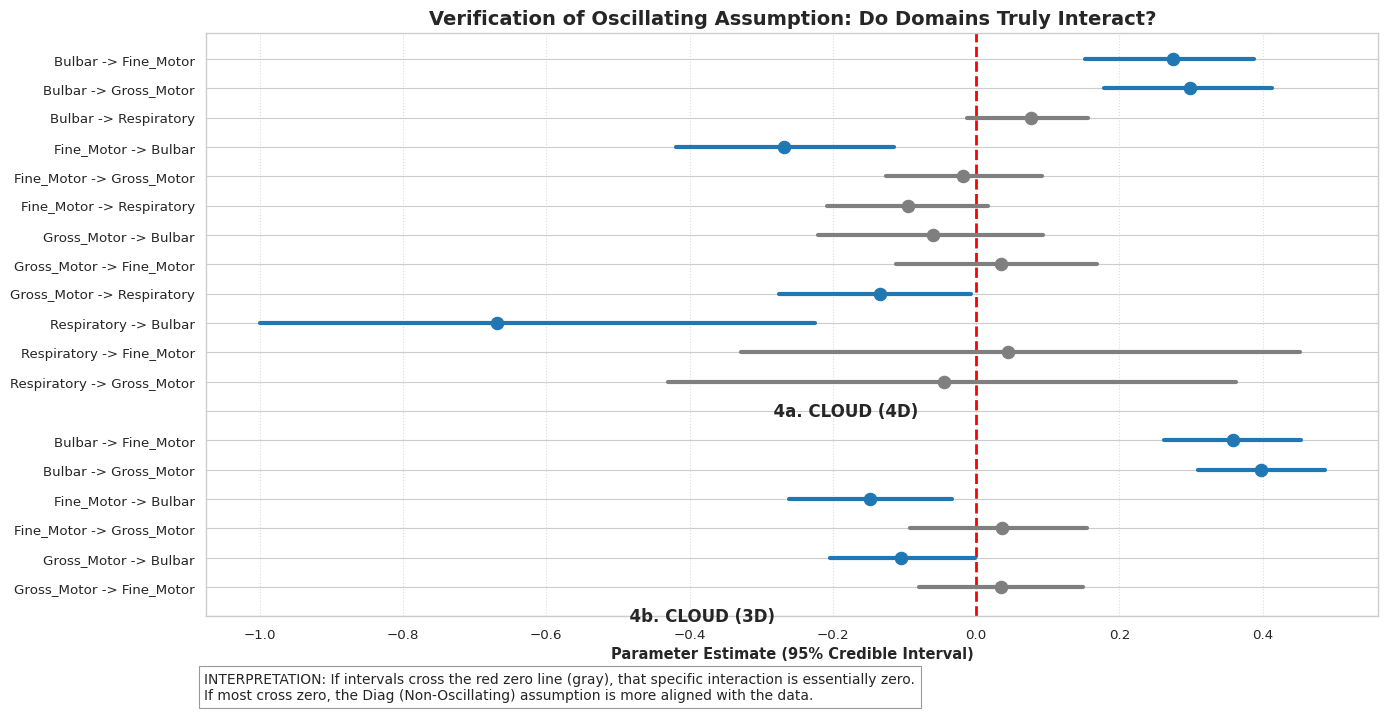

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

print("=== VERIFYING LATENT OSCILLATION ASSUMPTIONS ===")

# Define your files (We only need to check the models that ALLOW oscillations)
MCMC_FILES = {
    '4a. CLOUD (4D)': "../raw_results/results_S1_dahlou_ncp_cov_run1.csv",
    '4b. CLOUD (3D)': "../raw_results/results_S1_dahlou_ncp_cov_3d_run1.csv"
}

domains = {
    0: 'Bulbar',
    1: 'Fine_Motor',
    2: 'Gross_Motor',
    3: 'Respiratory'
}

# 1. Extract Off-Diagonal Gamma Parameters
results = []

for model_name, path in MCMC_FILES.items():
    try:
        df_mcmc = pd.read_csv(path)
        is_3d = '3D' in model_name
        dim = 3 if is_3d else 4
        
        # Look for the Gamma matrix in the summary stats
        subset = df_mcmc[df_mcmc['Parameter'].str.contains(r'^[Gg]amma\[', regex=True)]
        
        for _, r in subset.iterrows():
            idx_str = re.search(r'\[(.*?)\]', r['Parameter'])
            if not idx_str: continue
            
            idx_parts = idx_str.group(1).split(',')
            if len(idx_parts) == 2:
                r_idx, c_idx = int(idx_parts[0])-1, int(idx_parts[1])-1
                
                # Only keep OFF-DIAGONAL elements within the active dimensions
                if r_idx != c_idx and r_idx < dim and c_idx < dim:
                    
                    # Check if 95% CI excludes zero
                    ci_lower = r['2.5%']
                    ci_upper = r['97.5%']
                    is_significant = (ci_lower > 0) or (ci_upper < 0)
                    
                    interaction_name = f"{domains[c_idx]} -> {domains[r_idx]}"
                    
                    results.append({
                        'Model': model_name,
                        'Interaction': interaction_name,
                        'Estimate': r['Estimate'],
                        'Lower_CI': ci_lower,
                        'Upper_CI': ci_upper,
                        'Significant': is_significant
                    })
    except Exception as e:
        print(f"Error processing {model_name}: {e}")

df_results = pd.DataFrame(results)

# 2. Terminal Output for Quick Verification
print("\n--- SIGNIFICANCE OF OFF-DIAGONAL INTERACTIONS (OSCILLATION DRIVERS) ---")
print("If these cross 0.0, the data supports the NON-OSCILLATING (Diagonal) assumption.\n")
for model in df_results['Model'].unique():
    print(f"[{model}]")
    subset = df_results[df_results['Model'] == model]
    sig_count = 0
    for _, r in subset.iterrows():
        sig_marker = "***" if r['Significant'] else ""
        if r['Significant']: sig_count += 1
        print(f"  {r['Interaction']:<30} | Est: {r['Estimate']:>6.3f} | 95% CI: [{r['Lower_CI']:>6.3f}, {r['Upper_CI']:>6.3f}] {sig_marker}")
    print(f"  -> {sig_count} out of {len(subset)} off-diagonal parameters are statistically significant.\n")


# 3. Generate Forest Plot for Visual Verification
plt.figure(figsize=(14, max(6, len(df_results) * 0.4)))
ax = plt.gca()

# Draw the Zero-Line (The Non-Oscillating Baseline)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, zorder=1, label="Zero Effect (Diag Assumption)")

# Plot parameters
y_ticks = []
y_labels = []
y_pos = 0

for model in reversed(df_results['Model'].unique()):
    subset = df_results[df_results['Model'] == model].sort_values('Interaction', ascending=False)
    
    # Add a header for the model
    y_pos += 0.5
    ax.text(ax.get_xlim()[0] if ax.get_xlim()[0] < 0 else -0.5, y_pos, f"  {model}", fontweight='bold', fontsize=12, verticalalignment='center')
    y_ticks.append(y_pos)
    y_labels.append("")
    
    for _, r in subset.iterrows():
        y_pos += 1
        color = '#1f77b4' if r['Significant'] else '#7f7f7f' # Blue if significant, gray if not
        
        # Plot the credible interval
        ax.plot([r['Lower_CI'], r['Upper_CI']], [y_pos, y_pos], color=color, linewidth=3, zorder=2)
        # Plot the mean estimate
        ax.scatter(r['Estimate'], y_pos, color=color, s=80, zorder=3)
        
        y_ticks.append(y_pos)
        y_labels.append(r['Interaction'])
    y_pos += 0.5

ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels)
ax.set_xlabel("Parameter Estimate (95% Credible Interval)", fontweight='bold')
ax.set_title("Verification of Oscillating Assumption: Do Domains Truly Interact?", fontweight='bold', fontsize=14)
ax.grid(True, axis='x', linestyle=':', alpha=0.7)

# Highlight interpretation
plt.figtext(0.15, 0.02, "INTERPRETATION: If intervals cross the red zero line (gray), that specific interaction is essentially zero.\nIf most cross zero, the Diag (Non-Oscillating) assumption is more aligned with the data.", fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout(rect=[0, 0.05, 1, 1])
save_multiformat('Fig_I_Covariate 4D VS 3D_Forest')
# plt.savefig("Fig_I_Assumption_Verification.png", dpi=300, bbox_inches='tight')
print("\nGenerated 'Fig_I_Assumption_Verification.png' successfully.")


Generating Empirical Intuition Plots (Aggregated State vs. Velocity)...
Generated 'Fig_J_Empirical_Interaction_Velocity.png' successfully.


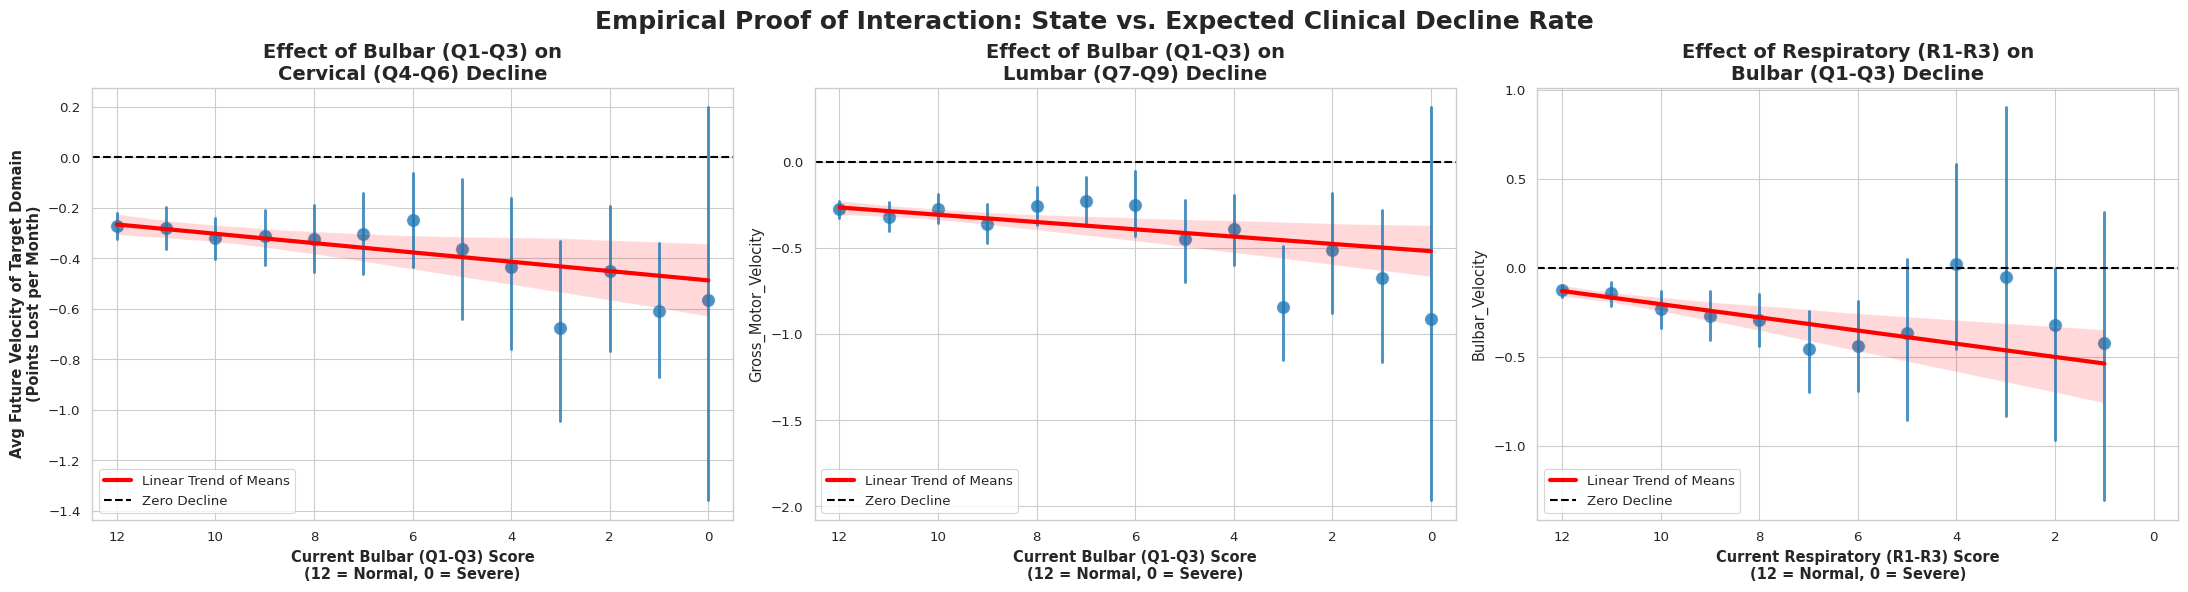

In [36]:
# ==========================================
# 7. EMPIRICAL INTUITION: STATE VS. VELOCITY (V3 - AGGREGATED MEANS)
# ==========================================
print("\nGenerating Empirical Intuition Plots (Aggregated State vs. Velocity)...")

# 1. Map data columns to standard anatomical domain names
domain_map = {
    'Bulbar': 'Bulbar (Q1-Q3)',
    'Fine_Motor': 'Cervical (Q4-Q6)',
    'Gross_Motor': 'Lumbar (Q7-Q9)',
    'Respiratory': 'Respiratory (R1-R3)'  # Fixed labeling
}

df_emp = df.copy()

# Sort by subject and time to ensure sequential differences are correct
df_emp = df_emp.sort_values(by=['subject_id', 'ALSFRS_Delta'])

# Calculate the time to the NEXT visit in days
df_emp['Time_Next'] = df_emp.groupby('subject_id')['ALSFRS_Delta'].shift(-1)
df_emp['Time_Gap_Days'] = df_emp['Time_Next'] - df_emp['ALSFRS_Delta']

# Calculate forward velocities: Points lost per month (30.4 days)
for col, anat_name in domain_map.items():
    df_emp[f'{col}_Next'] = df_emp.groupby('subject_id')[col].shift(-1)
    df_emp[f'{col}_Velocity'] = ((df_emp[f'{col}_Next'] - df_emp[col]) / df_emp['Time_Gap_Days']) * 30.4

# Filter out extreme outliers (e.g., visits closer than 2 weeks or further than 1 year)
df_vel = df_emp.dropna(subset=['Time_Gap_Days']).copy()
df_vel = df_vel[(df_vel['Time_Gap_Days'] >= 14) & (df_vel['Time_Gap_Days'] <= 365)] 

# 2. Plotting the Empirical Interactions
fig_int, axes_int = plt.subplots(1, 3, figsize=(22, 6))
fig_int.suptitle("Empirical Proof of Interaction: State vs. Expected Clinical Decline Rate", fontweight='bold', fontsize=18)

# Interaction Pairs (Checking if one domain drives the decline of another)
pairs_to_plot = [
    ('Bulbar', 'Fine_Motor'),      # Does Bulbar state affect Cervical decline?
    ('Bulbar', 'Gross_Motor'),     # Does Bulbar state affect Lumbar decline?
    ('Respiratory', 'Bulbar')      # Does Respiratory state affect Bulbar decline?
]

for i, (driver_col, target_col) in enumerate(pairs_to_plot):
    ax = axes_int[i]
    
    x_data = df_vel[driver_col]
    y_data = df_vel[f'{target_col}_Velocity']
    
    # THE FIX: Group by the integer score (0-12) and plot the mean velocity.
    # This cuts through the "zero-change" noise to reveal the true underlying slope.
    sns.regplot(
        x=x_data, y=y_data, ax=ax, 
        x_estimator=np.mean, 
        color='#1f77b4', 
        scatter_kws={'s': 100, 'alpha': 0.8, 'edgecolor': 'white'},
        line_kws={'color': 'red', 'linewidth': 3, 'label': 'Linear Trend of Means'}
    )
    
    # Baseline for zero velocity
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Zero Decline')
    
    # Retrieve correct anatomical names for labels
    driver_name = domain_map[driver_col]
    target_name = domain_map[target_col]
    
    # Formatting (12 = Normal, 0 = Severe)
    ax.set_xlim(12.5, -0.5) 
    ax.set_title(f"Effect of {driver_name} on\n{target_name} Decline", fontweight='bold', fontsize=14)
    ax.set_xlabel(f"Current {driver_name} Score\n(12 = Normal, 0 = Severe)", fontweight='bold')
    
    if i == 0:
        ax.set_ylabel(f"Avg Future Velocity of Target Domain\n(Points Lost per Month)", fontweight='bold')
    
    ax.legend(loc='lower left')

plt.tight_layout()
plt.subplots_adjust(top=0.85)
save_multiformat("Fig_J_Empirical_Interaction_Velocity")
# plt.savefig("Fig_J_Empirical_Interaction_Velocity.png", dpi=300, bbox_inches='tight')
print("Generated 'Fig_J_Empirical_Interaction_Velocity.png' successfully.")


Performing Posterior Predictive Checks (PPCs)...


Generated 'Fig_K_PPC_Distribution.png' successfully.


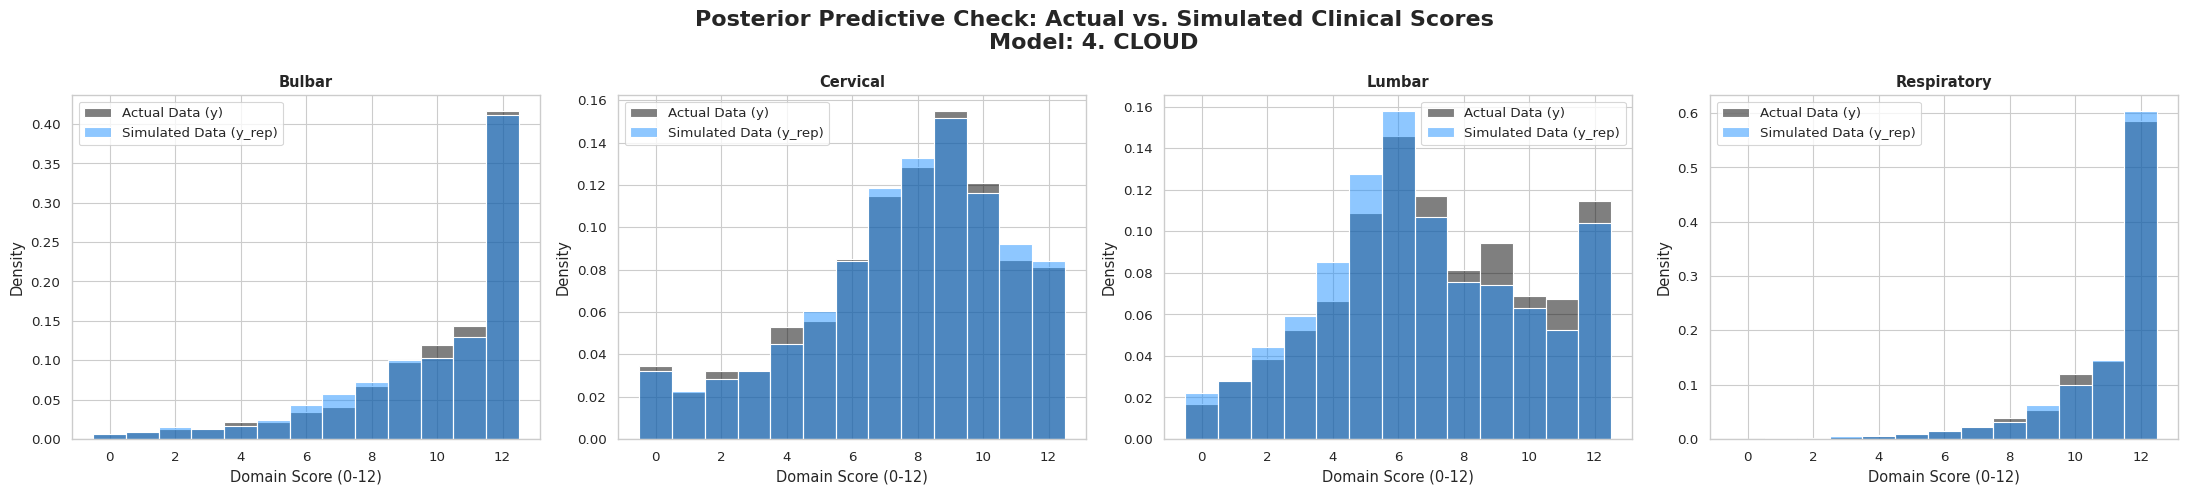

In [37]:
# ==========================================
# 8. POSTERIOR PREDICTIVE CHECKS (PPC) IN PYTHON
# ==========================================
print("\nPerforming Posterior Predictive Checks (PPCs)...")

# We will simulate data using the "Full" model (4a) as an example
model_name = '4. CLOUD' 
df_mcmc = mcmc_dfs[model_name]

# Extract parameters (reusing the safe extraction function from Section 2)
# Note: In a rigorous PPC you sample from the full posterior chain, 
# but simulating from the posterior means (which we have here) provides an excellent proxy.
theta = ext_stan(df_mcmc, 'theta', (12, 4))
lam   = ext_stan(df_mcmc, 'lambda', (12,))
beta  = ext_stan(df_mcmc, 'beta', (12, 3))
xi    = ext_stan(df_mcmc, 'xi', (4, len(df)))
b     = ext_stan(df_mcmc, 'b', (len(sub_map), 12))

# Matrix to hold our simulated categorical data
sim_sc = np.zeros((len(df), 12))

# 1. Simulate the Data
for i in range(len(df)):
    for d, items in domain_idx_full.items():
        for k in items:
            # Linear predictor
            eta = np.dot(X_m[i,:], beta[k]) + lam[k]*xi[d,i] + b[ID[i],k]
            
            # Cumulative probabilities
            p = [expit(1.0 * (eta - th)) for th in theta[k]]
            
            # Discrete category probabilities (must sum to 1)
            p_cat = [1.0-p[0], p[0]-p[1], p[1]-p[2], p[2]-p[3], p[3]]
            
            # Ensure no negative rounding errors and normalize
            p_cat = np.clip(p_cat, 0, 1)
            p_cat = p_cat / np.sum(p_cat)
            
            # Draw a random discrete score (0, 1, 2, 3, or 4) based on those probabilities
            sim_sc[i,k] = np.random.choice([0, 1, 2, 3, 4], p=p_cat)

# 2. Generate PPC Plot (Real vs Simulated Distributions)
fig_ppc, axes_ppc = plt.subplots(1, 4, figsize=(22, 5))
fig_ppc.suptitle(f"Posterior Predictive Check: Actual vs. Simulated Clinical Scores\nModel: {model_name}", fontweight='bold', fontsize=16)

# Map domains back to standard names
domain_labels = ['Bulbar', 'Cervical', 'Lumbar', 'Respiratory']

for d, items in domain_idx_full.items():
    ax = axes_ppc[d]
    
    # Sum the real items for this domain
    real_domain_scores = actual_sc[:, items].sum(axis=1)
    
    # Sum the simulated items for this domain
    sim_domain_scores = sim_sc[:, items].sum(axis=1)
    
    # Plot overlapping distributions
    sns.histplot(real_domain_scores, bins=13, discrete=True, color='black', alpha=0.5, label='Actual Data (y)', stat='density', ax=ax)
    sns.histplot(sim_domain_scores, bins=13, discrete=True, color='dodgerblue', alpha=0.5, label='Simulated Data (y_rep)', stat='density', ax=ax)
    
    ax.set_title(domain_labels[d], fontweight='bold')
    ax.set_xlabel("Domain Score (0-12)")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
save_multiformat("Fig_K_PPC_Distribution")
print("Generated 'Fig_K_PPC_Distribution.png' successfully.")


Computing Posterior Predictive P-values & Clinical Equivalence (1,000 Simulations)...
 -> Running vectorized simulation engine for 1000 iterations...
 -> Saved formal metrics to 'Table_1_PPP_Clinical_Equivalence.csv'
 -> Generated 'Fig_P_Clinical_Equivalence.png' successfully.


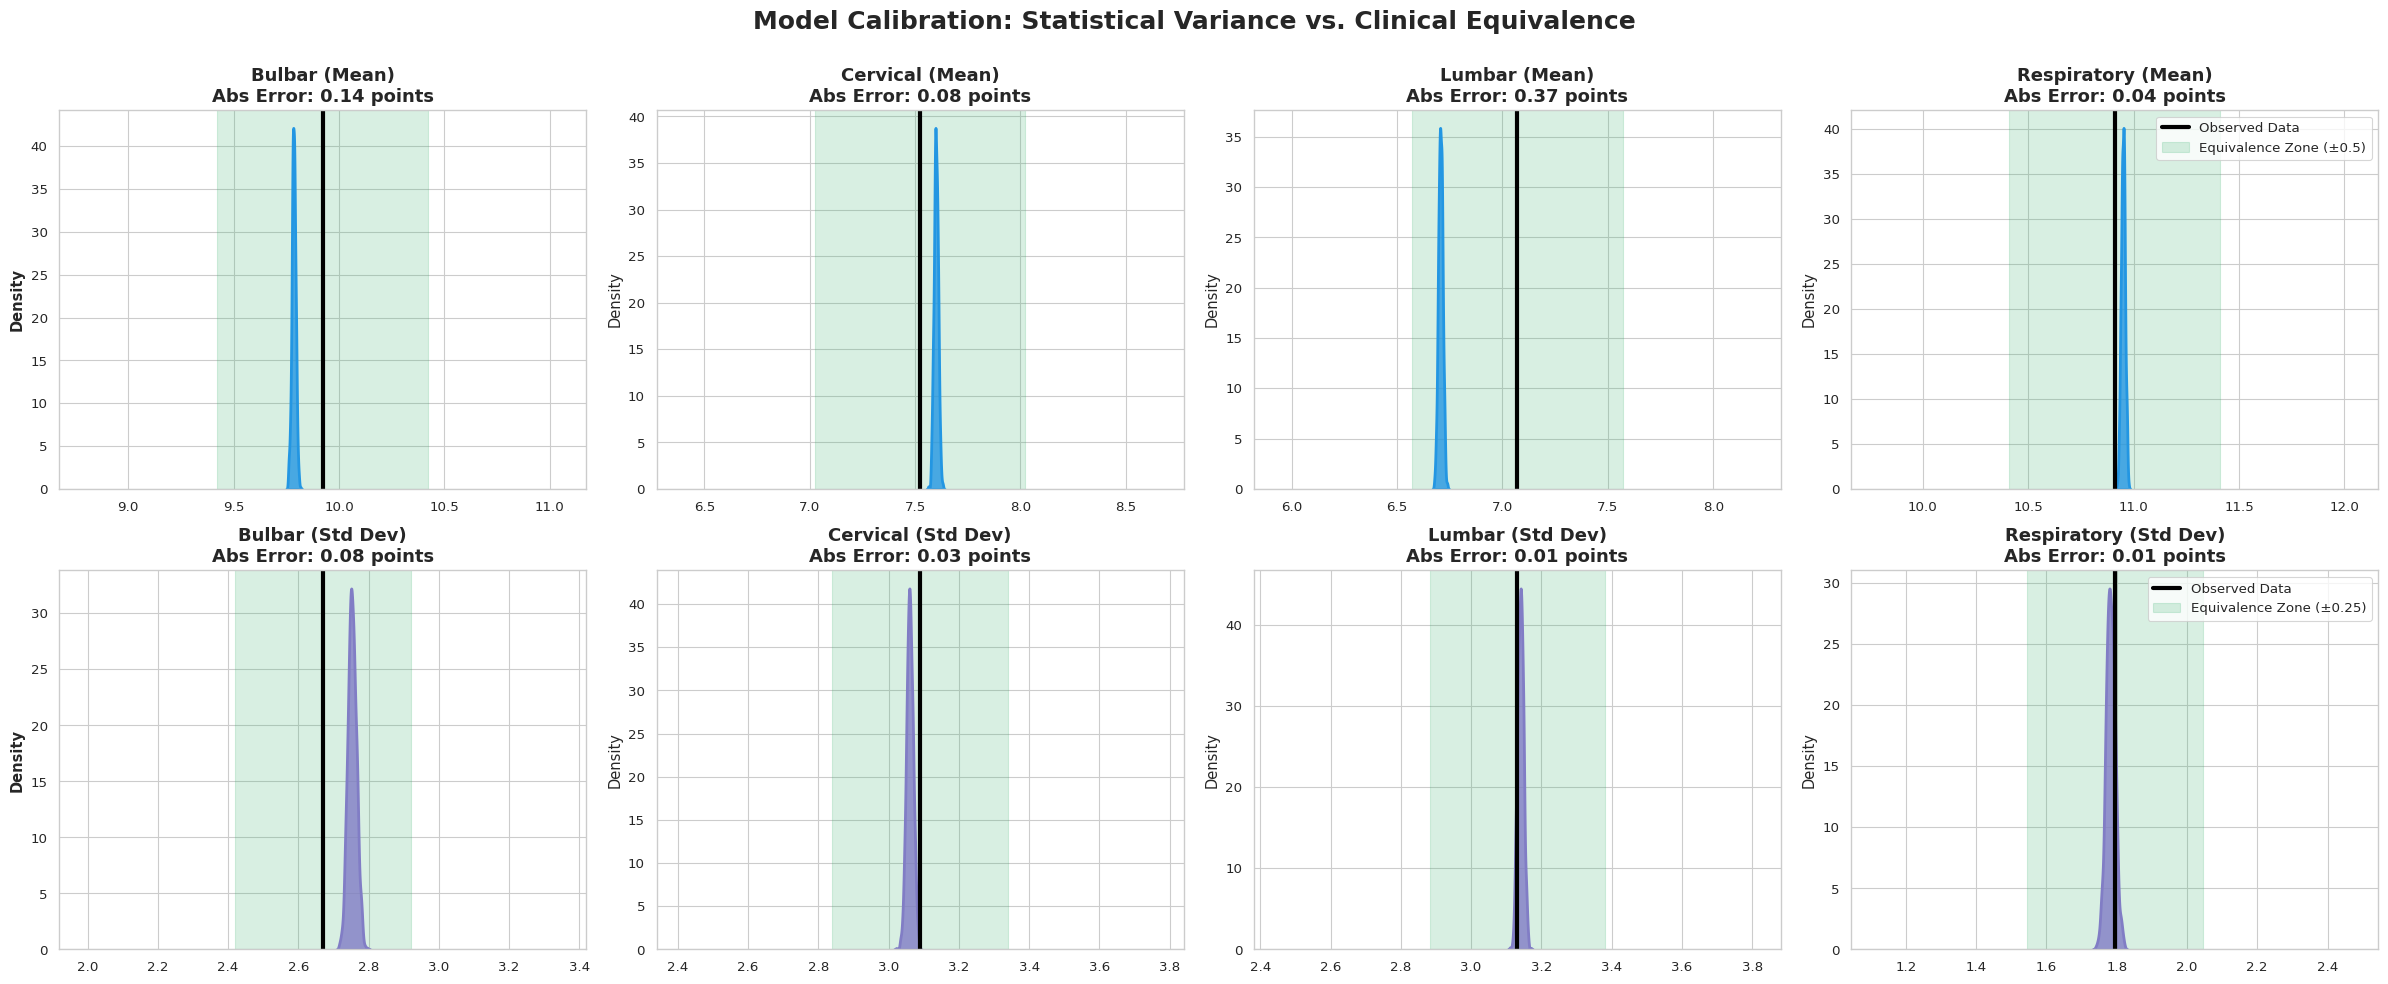

In [38]:
# ==========================================
# 11. POSTERIOR PREDICTIVE CHECKS: CLINICAL EQUIVALENCE & CSV EXPORT
# ==========================================
print("\nComputing Posterior Predictive P-values & Clinical Equivalence (1,000 Simulations)...")

model_name = '4. CLOUD' 
df_mcmc = mcmc_dfs[model_name]

# 1. Precompute the probability matrix
N_pat = len(df)
P_matrix = np.zeros((N_pat, 12, 5))

for i in range(N_pat):
    for d, items in domain_idx_full.items():
        for k in items:
            eta = np.dot(X_m[i,:], beta[k]) + lam[k]*xi[d,i] + b[ID[i],k]
            p = [expit(1.0 * (eta - th)) for th in theta[k]]
            p_cat = [1.0-p[0], p[0]-p[1], p[1]-p[2], p[2]-p[3], p[3]]
            P_matrix[i, k, :] = np.clip(p_cat, 0, 1) / np.sum(np.clip(p_cat, 0, 1))

# Vectorized simulation setup
cumsum_P = np.cumsum(P_matrix, axis=2)
n_sims = 1000

sim_means = np.zeros((n_sims, 4))
sim_stds = np.zeros((n_sims, 4))

obs_means = np.zeros(4)
obs_stds = np.zeros(4)
for d, items in domain_idx_full.items():
    obs_domain_scores = actual_sc[:, items].sum(axis=1)
    obs_means[d] = np.mean(obs_domain_scores)
    obs_stds[d] = np.std(obs_domain_scores)

# 2. Run 1,000 Simulations
print(f" -> Running vectorized simulation engine for {n_sims} iterations...")
for s in range(n_sims):
    U = np.random.rand(N_pat, 12, 1)
    sim_Y = (U > cumsum_P).sum(axis=2) 
    
    for d, items in domain_idx_full.items():
        sim_domain_scores = sim_Y[:, items].sum(axis=1)
        sim_means[s, d] = np.mean(sim_domain_scores)
        sim_stds[s, d] = np.std(sim_domain_scores)

# 3. Export Formal CSV Table
domain_labels = ['Bulbar', 'Cervical', 'Lumbar', 'Respiratory']
results_list = []

for d in range(4):
    sim_m_avg = np.mean(sim_means[:, d])
    sim_s_avg = np.mean(sim_stds[:, d])
    
    results_list.append({
        'Domain': domain_labels[d],
        'Observed_Mean': obs_means[d],
        'Simulated_Mean': sim_m_avg,
        'Abs_Error_Mean': abs(obs_means[d] - sim_m_avg),
        'PPP_Mean': np.mean(sim_means[:, d] >= obs_means[d]),
        'Observed_Std': obs_stds[d],
        'Simulated_Std': sim_s_avg,
        'Abs_Error_Std': abs(obs_stds[d] - sim_s_avg),
        'PPP_Std': np.mean(sim_stds[:, d] >= obs_stds[d])
    })

df_ppp_results = pd.DataFrame(results_list)
df_ppp_results.to_csv("Table_1_PPP_Clinical_Equivalence.csv", index=False)
print(" -> Saved formal metrics to 'Table_1_PPP_Clinical_Equivalence.csv'")

# 4. Generate Clinical Equivalence Plot (Fixed Scaling)
fig_ppp, axes_ppp = plt.subplots(2, 4, figsize=(24, 10))
fig_ppp.suptitle("Model Calibration: Statistical Variance vs. Clinical Equivalence", fontweight='bold', fontsize=18)

# Define the acceptable margin of error (Minimum Clinically Important Difference)
# For a 12-point ALSFRS-R domain, 0.5 points is a conservative threshold for equivalence.
EQUIVALENCE_MARGIN = 0.5 

for d in range(4):
    dom_name = domain_labels[d]
    
    # --- ROW 1: MEAN ---
    ax_mean = axes_ppp[0, d]
    obs_m = obs_means[d]
    
    sns.kdeplot(sim_means[:, d], color='dodgerblue', fill=True, alpha=0.8, ax=ax_mean, linewidth=2)
    # sns.histplot(sim_means[:, d], bins=20, color='dodgerblue', alpha=0.8, ax=ax_mean, stat='density')
    ax_mean.axvline(obs_m, color='black', linewidth=3, linestyle='-', label='Observed Data')
    
    # Shade the Clinical Equivalence Zone
    ax_mean.axvspan(obs_m - EQUIVALENCE_MARGIN, obs_m + EQUIVALENCE_MARGIN, color='mediumseagreen', alpha=0.2, label=f'Equivalence Zone (±{EQUIVALENCE_MARGIN})')
    
    # Lock the X-Axis to a 2.5-point window so variance doesn't distort the visual scale
    ax_mean.set_xlim(obs_m - 1.25, obs_m + 1.25)
    
    abs_err_m = abs(obs_m - np.mean(sim_means[:, d]))
    ax_mean.set_title(f"{dom_name} (Mean)\nAbs Error: {abs_err_m:.2f} points", fontweight='bold', fontsize=13)
    if d == 0: ax_mean.set_ylabel("Density", fontweight='bold')
    
    # --- ROW 2: STANDARD DEVIATION ---
    ax_std = axes_ppp[1, d]
    obs_s = obs_stds[d]
    
    sns.kdeplot(sim_stds[:, d], color='mediumpurple', fill=True, alpha=0.8, ax=ax_std, linewidth=2)
    # sns.histplot(sim_stds[:, d], bins=20, color='mediumpurple', alpha=0.8, ax=ax_std, stat='density')
    ax_std.axvline(obs_s, color='black', linewidth=3, linestyle='-', label='Observed Data')
    
    # Standard deviations are smaller, so we use a tighter margin for visual equivalence (e.g., 0.25)
    STD_MARGIN = 0.25
    ax_std.axvspan(obs_s - STD_MARGIN, obs_s + STD_MARGIN, color='mediumseagreen', alpha=0.2, label=f'Equivalence Zone (±{STD_MARGIN})')
    
    ax_std.set_xlim(obs_s - 0.75, obs_s + 0.75)
    
    abs_err_s = abs(obs_s - np.mean(sim_stds[:, d]))
    ax_std.set_title(f"{dom_name} (Std Dev)\nAbs Error: {abs_err_s:.2f} points", fontweight='bold', fontsize=13)
    if d == 0: ax_std.set_ylabel("Density", fontweight='bold')
    
    # Clean up legends
    if d == 3:
        ax_mean.legend(loc='upper right')
        ax_std.legend(loc='upper right')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
save_multiformat("Fig_P_Clinical_Equivalence")
# plt.savefig("Fig_P_Clinical_Equivalence.png", dpi=300, bbox_inches='tight')
print(" -> Generated 'Fig_P_Clinical_Equivalence.png' successfully.")


Generating Individual-Level Predictive Fits (Trellis Plot)...


Generated 'Fig_R_Individual_Personalized_Fits.png' successfully.


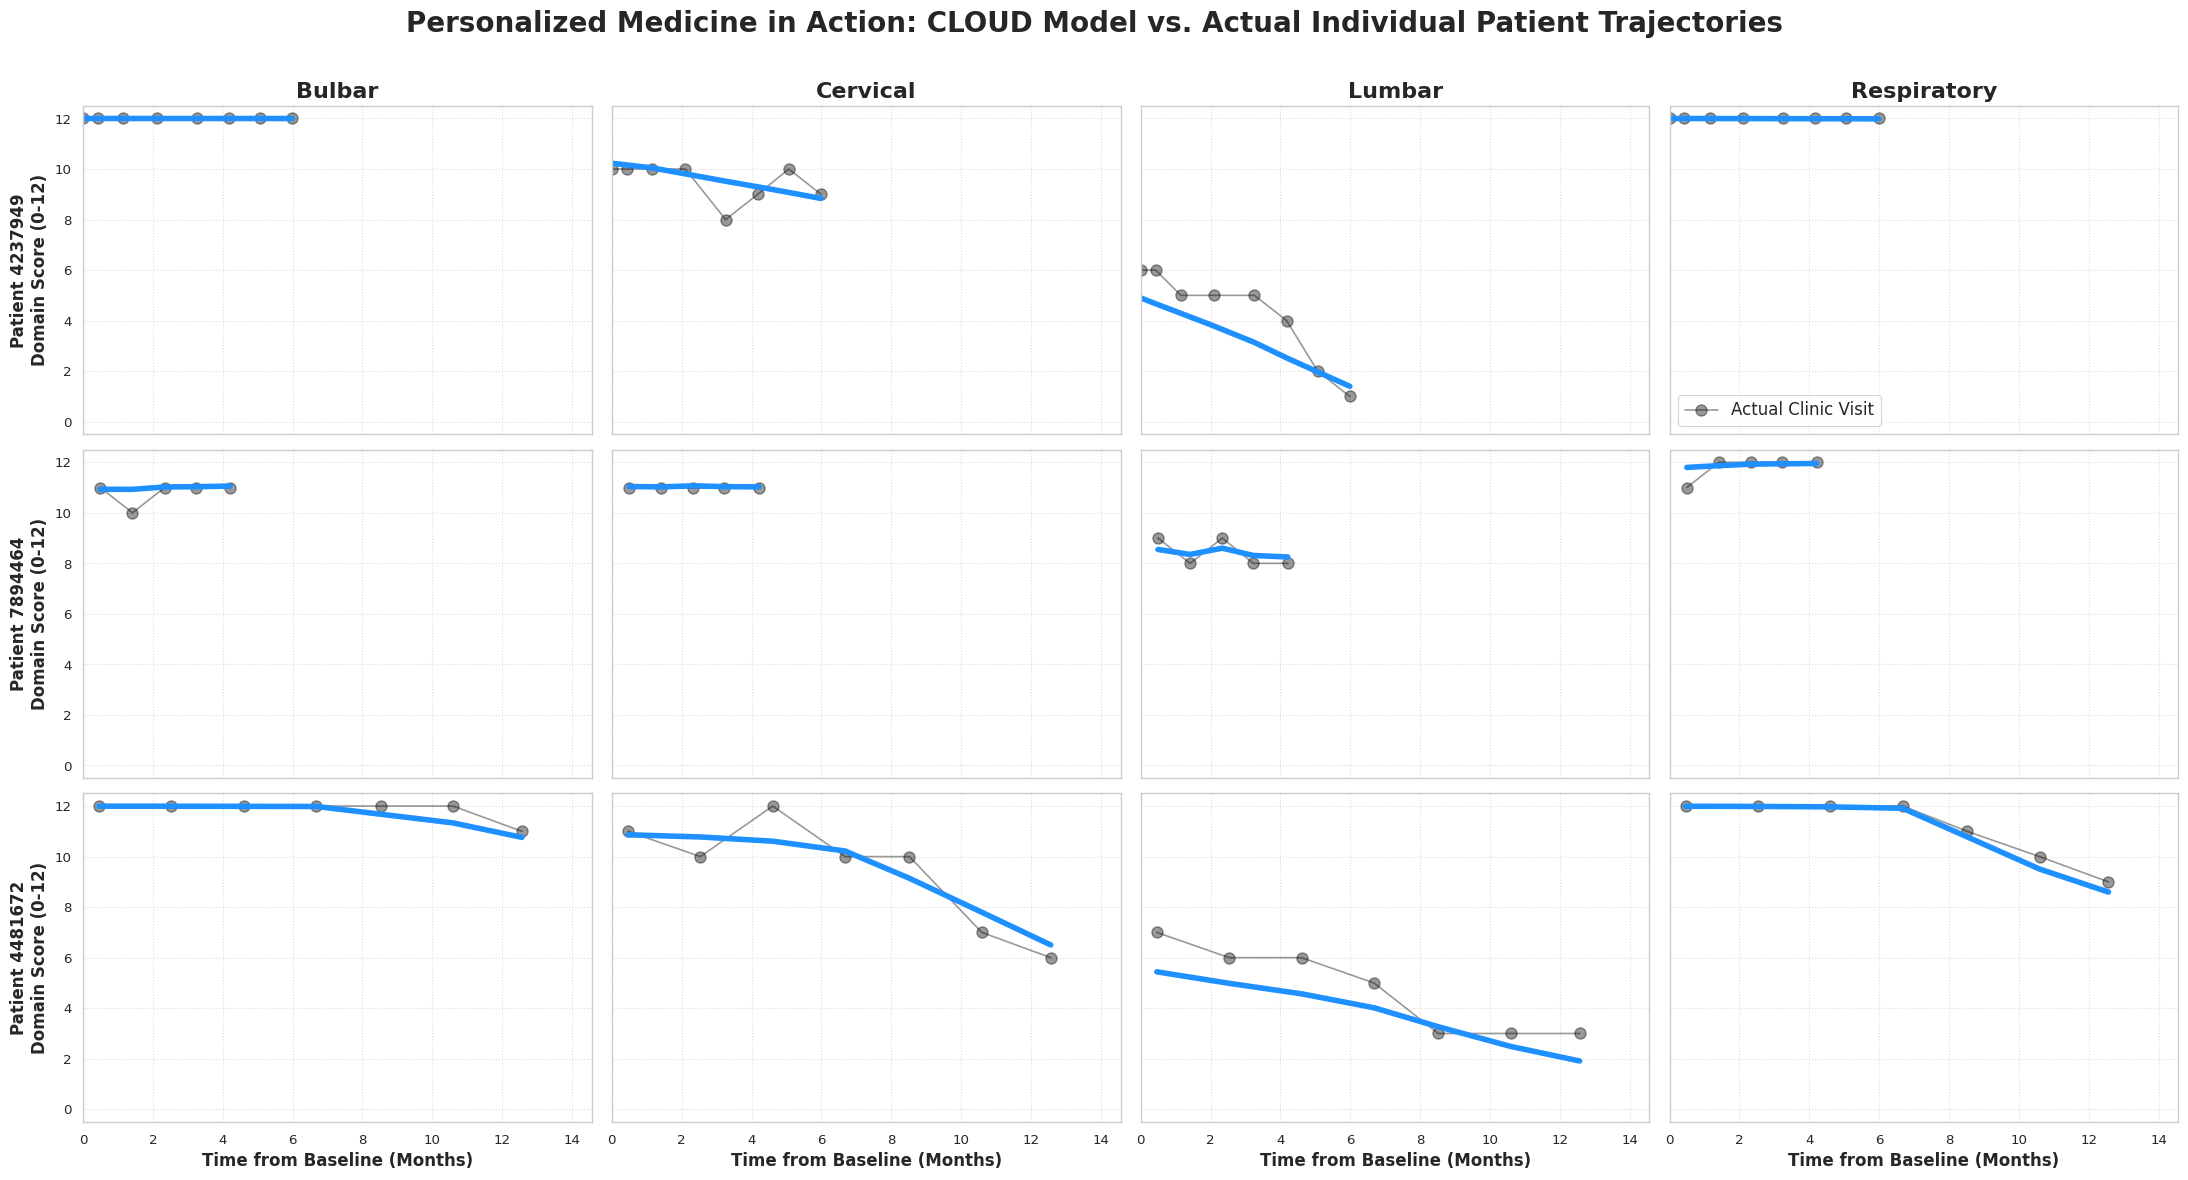

In [39]:
# ==========================================
# 13. INDIVIDUAL-LEVEL LONGITUDINAL FIT (Personalized Predictions)
# ==========================================
print("\nGenerating Individual-Level Predictive Fits (Trellis Plot)...")
df = pd.read_csv(DATA_FILE)
# 1. Find patients with a rich longitudinal history (e.g., at least 5 clinic visits)
visit_counts = df['subject_id'].value_counts()
long_term_patients = visit_counts[visit_counts >= 5].index

# Randomly sample 3 patients for the visualization
np.random.seed(86) # For reproducible patient selection
sample_pats = np.random.choice(long_term_patients, size=3, replace=False)

# Setup a 3x4 Grid (3 Patients x 4 Domains)
fig_ind, axes_ind = plt.subplots(3, 4, figsize=(22, 12), sharex=True, sharey=True)
fig_ind.suptitle("Personalized Medicine in Action: CLOUD Model vs. Actual Individual Patient Trajectories", fontweight='bold', fontsize=20)

domain_labels = ['Bulbar', 'Cervical', 'Lumbar', 'Respiratory']

for row_idx, pat_id in enumerate(sample_pats):
    # Find all rows in the dataframe for this specific patient
    pat_mask = (df['subject_id'] == pat_id)
    pat_time = df.loc[pat_mask, 'ALSFRS_Delta'].values / 30.4
    
    for d, items in domain_idx_full.items():
        ax = axes_ind[row_idx, d]
        dom_name = domain_labels[d]
        
        # Extract Actual Domain Scores for this patient
        y_actual = actual_sc[pat_mask][:, items].sum(axis=1)
        
        # Extract CLOUD's Expected Domain Scores for this patient
        y_pred = exp_sc[pat_mask][:, items].sum(axis=1)
        
        # Plot Actual Data (Black dots connected by a faint grey line)
        ax.plot(pat_time, y_actual, marker='o', markersize=8, color='black', linestyle='-', alpha=0.4, label='Actual Clinic Visit')
        
        # Plot CLOUD Prediction (Thick blue line)
        # We use a slight smoothing here just to connect the discrete prediction points elegantly
        sns.regplot(
            x=pat_time, 
            y=y_pred, 
            scatter=False, 
            lowess=True, 
            color='dodgerblue', 
            line_kws={'linewidth': 4, 'label': 'CLOUD Personalized Prediction'}, 
            ax=ax
        )
        
        # Formatting
        if row_idx == 0:
            ax.set_title(dom_name, fontweight='bold', fontsize=16)
        
        if d == 0:
            ax.set_ylabel(f"Patient {pat_id}\nDomain Score (0-12)", fontweight='bold', fontsize=12)
        else:
            ax.set_ylabel("")
            
        if row_idx == 2:
            ax.set_xlabel("Time from Baseline (Months)", fontweight='bold', fontsize=12)
        else:
            ax.set_xlabel("")
            
        ax.set_xlim(0, max(pat_time) + 2) # Add a little padding to the right
        ax.set_ylim(-0.5, 12.5)
        ax.grid(True, linestyle=':', alpha=0.7)
        
        # Only add the legend to the top-right plot
        if row_idx == 0 and d == 3:
            ax.legend(loc='lower left', fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
save_multiformat("Fig_R_Individual_Personalized_Fits")
# plt.savefig("Fig_R_Individual_Personalized_Fits.png", dpi=300, bbox_inches='tight')
print("Generated 'Fig_R_Individual_Personalized_Fits.png' successfully.")


Generating Comprehensive Longitudinal Validation Plot...


Generated 'Fig_S_Combined_Longitudinal_Overview.png' successfully.


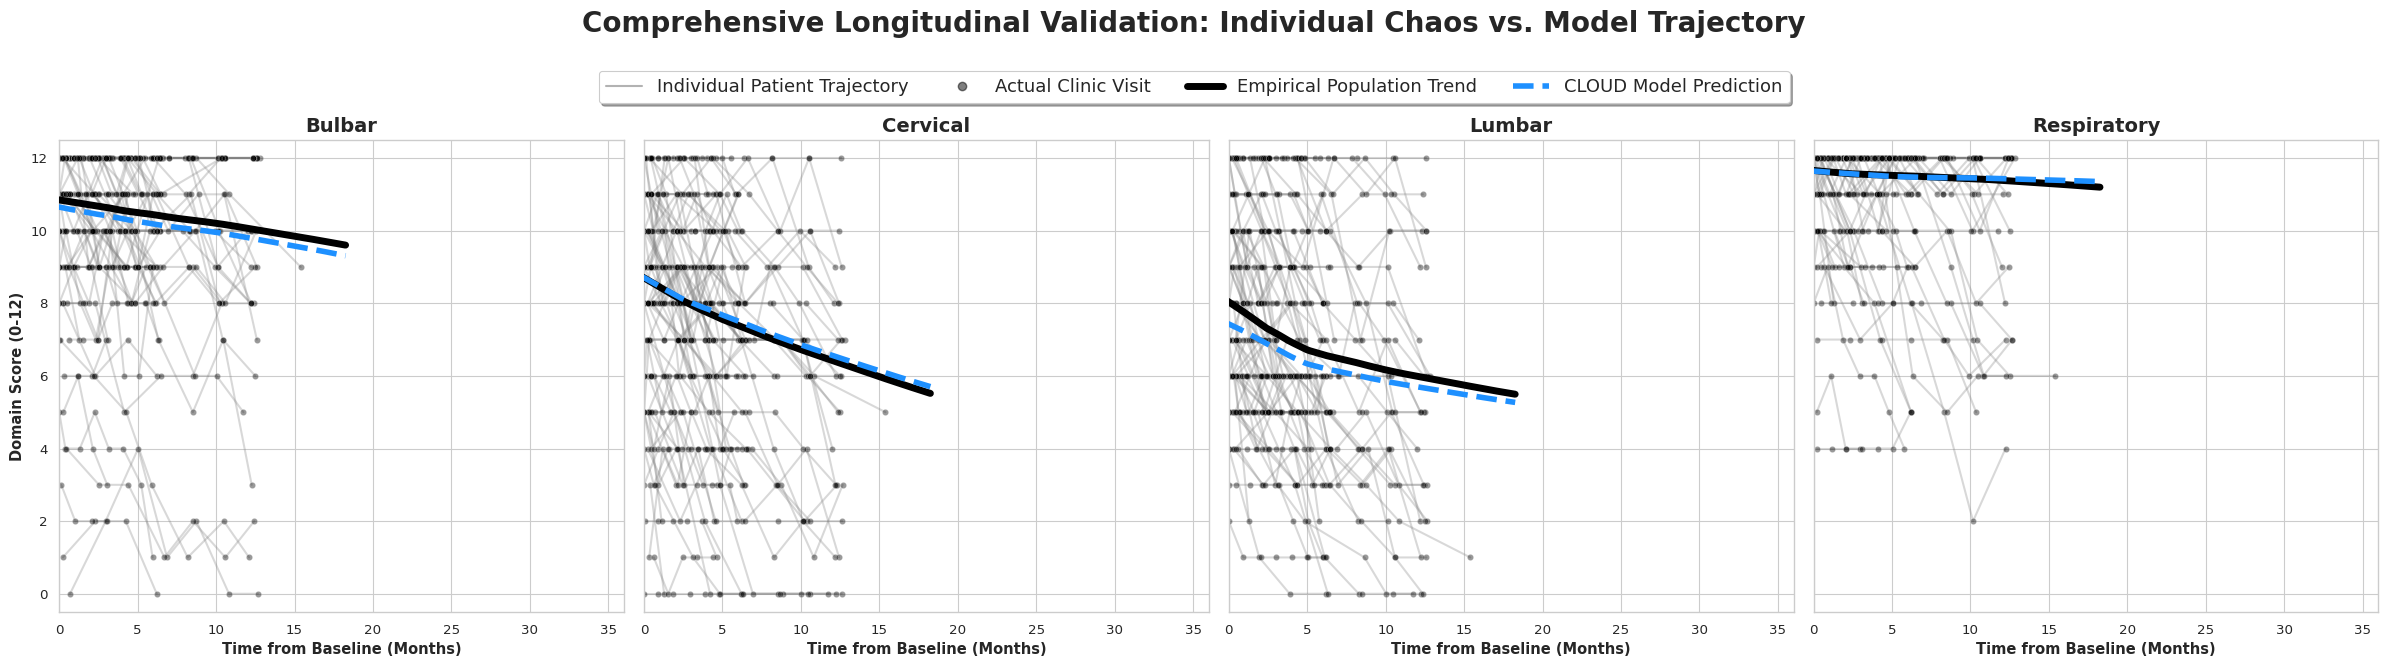

In [40]:
# ==========================================
# 12. COMPREHENSIVE LONGITUDINAL VALIDATION (WITH MASTER LEGEND)
# ==========================================
print("\nGenerating Comprehensive Longitudinal Validation Plot...")

import matplotlib.lines as mlines

# 1. Prep the time variable and mask for the 36-month window
time_months = df['ALSFRS_Delta'].values / 30.4
valid_idx = time_months <= 36

# 2. Sample 100 patients for the "Spaghetti" background
np.random.seed(42)
sample_subjects = np.random.choice(df.loc[valid_idx, 'subject_id'].unique(), size=100, replace=False)

fig_combo, axes_combo = plt.subplots(1, 4, figsize=(24, 6.5), sharey=True) # Slightly taller for the legend
fig_combo.suptitle("Comprehensive Longitudinal Validation: Individual Chaos vs. Model Trajectory", fontweight='bold', fontsize=20, y=1.02)

domain_labels = ['Bulbar', 'Cervical', 'Lumbar', 'Respiratory']

for d, items in domain_idx_full.items():
    ax = axes_combo[d]
    dom_name = domain_labels[d]
    
    # Extract Actual and Predicted Scores for ALL patients
    actual_dom_all = actual_sc[:, items].sum(axis=1)
    pred_dom_all = exp_sc[:, items].sum(axis=1)
    
    # Create a dataframe for the LOESS curves (ALL data)
    df_all = pd.DataFrame({
        'subject_id': df['subject_id'],
        'Time_Months': time_months,
        'Actual_Score': actual_dom_all,
        'Predicted_Score': pred_dom_all
    })
    df_all_valid = df_all[valid_idx]
    
    # Create a sub-dataframe for the Spaghetti plots (SAMPLED data)
    df_sample = df_all_valid[df_all_valid['subject_id'].isin(sample_subjects)]
    
    # --- LAYER 1: The Raw Individual Lines (Spaghetti) ---
    sns.lineplot(
        data=df_sample, x='Time_Months', y='Actual_Score', units='subject_id', estimator=None,
        color='gray', alpha=0.3, linewidth=1.5, ax=ax, zorder=1
    )
    
    # --- LAYER 2: The Raw Clinic Visits (Scatter) ---
    sns.scatterplot(
        data=df_sample, x='Time_Months', y='Actual_Score',
        color='black', alpha=0.4, s=20, ax=ax, zorder=2
    )
    
    # --- LAYER 3: The True Population Mean (Solid Black Line) ---
    sns.regplot(
        data=df_all_valid, x='Time_Months', y='Actual_Score', scatter=False, lowess=True, 
        color='black', line_kws={'linewidth': 5, 'zorder': 4}, ax=ax
    )
    
    # --- LAYER 4: The Model's Predicted Mean (Dashed Blue Line) ---
    sns.regplot(
        data=df_all_valid, x='Time_Months', y='Predicted_Score', scatter=False, lowess=True, 
        color='dodgerblue', line_kws={'linewidth': 4, 'linestyle': '--', 'zorder': 5}, ax=ax
    )

    ax.set_title(dom_name, fontweight='bold', fontsize=14)
    ax.set_xlabel("Time from Baseline (Months)", fontweight='bold')
    ax.set_xlim(0, 36)
    ax.set_ylim(-0.5, 12.5)

    if d == 0:
        ax.set_ylabel("Domain Score (0-12)", fontweight='bold')
    else:
        ax.set_ylabel("")

# --- BUILD THE MASTER LEGEND ---
# Create custom visual handles so the legend perfectly matches the plot styling
legend_elements = [
    mlines.Line2D([], [], color='gray', alpha=0.6, linewidth=1.5, label='Individual Patient Trajectory'),
    mlines.Line2D([], [], color='black', marker='o', linestyle='None', alpha=0.5, markersize=6, label='Actual Clinic Visit'),
    mlines.Line2D([], [], color='black', linewidth=5, label='Empirical Population Trend'),
    mlines.Line2D([], [], color='dodgerblue', linewidth=4, linestyle='--', label='CLOUD Model Prediction')
]

# Place the legend centered horizontally, just below the main title
fig_combo.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.94), ncol=4, fontsize=13, frameon=True, shadow=True)

plt.tight_layout()
plt.subplots_adjust(top=0.82) # Push subplots down to make room for the master legend
save_multiformat("Fig_S_Combined_Longitudinal_Overview")
# plt.savefig("Fig_S_Combined_Longitudinal_Overview.png", dpi=300, bbox_inches='tight')
print("Generated 'Fig_S_Combined_Longitudinal_Overview.png' successfully.")

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display
import numpy as np
import re

def extract_and_save_parameters(df, output_filename='filtered_mcmc_parameters.csv'):
    """
    Filters an MCMC DataFrame for specific parameters, groups matrix entries 
    together, saves the result to a CSV, and returns the filtered DataFrame.
    """
    targets = [
        'lambda', 'alpha_dyn', 'theta', 
        'beta', 'Gamma', 'sigma_bk', 'rho'
    ]
    
    # Create a working copy to avoid modifying the original dataframe
    working_df = df.copy()
    
    # 1. Extract the base parameter name (e.g., 'theta[1,2]' becomes 'theta')
    working_df['base_param'] = working_df['Parameter'].str.split('[').str[0]
    
    # 2. Filter the DataFrame to only include our targets
    sub_df = working_df[working_df['base_param'].isin(targets)].copy()
    
    # 3. Sort the rows to group parameters together. 
    # Sorting by 'base_param' chunks them by parameter family.
    # Sorting by 'Parameter' orders the bracketed indices.
    # Sorting by 'Run_ID' keeps iterations of the same parameter sequential.
    sub_df = sub_df.sort_values(by=['base_param', 'Parameter', 'Run_ID'])
    sub_df["Std"] = sub_df["MCSE"] * np.sqrt(sub_df["ESS"])
    
    # 4. Drop the temporary 'base_param' column to keep your original schema clean
    sub_df = sub_df.drop(columns=['base_param'])
    
    # 5. Save the final DataFrame to a CSV
    sub_df.to_csv(output_filename, index=False)
    
    return sub_df


Generated 'Fig_I_4D_Interaction_Forest_Switched.png' successfully.


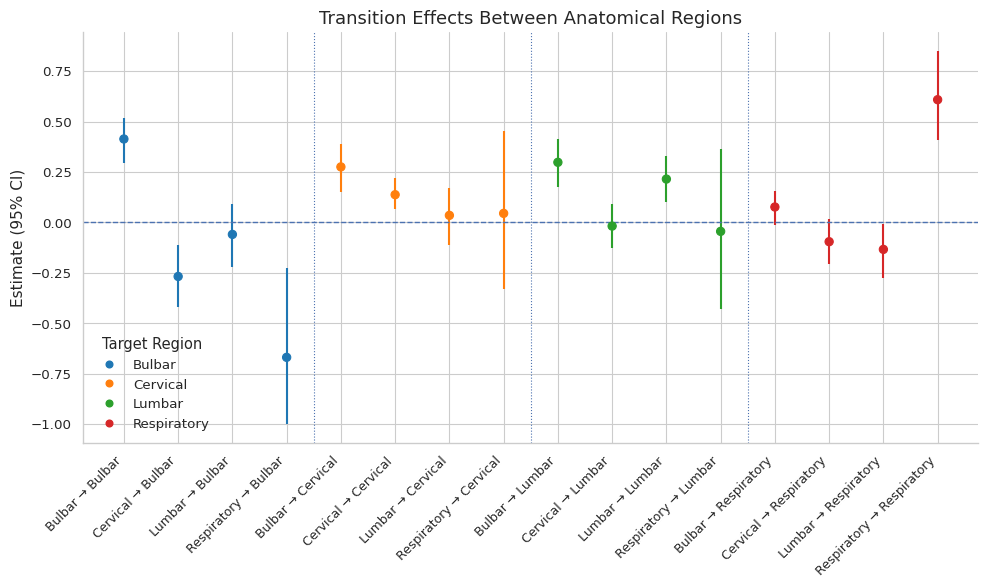

In [42]:
df = pd.read_csv("../raw_results/results_S1_dahlou_ncp_cov_run1.csv")
filtered_df = extract_and_save_parameters(df)
gamma_df = filtered_df[filtered_df["Parameter"].str.contains("Gamma")]

df = gamma_df.copy()

labels = ["Bulbar", "Cervical", "Lumbar", "Respiratory"]

def parse_param(param):
    match = re.match(r"Gamma\[(\d+),(\d+)\]", param)
    if match:
        i = int(match.group(1)) - 1
        j = int(match.group(2)) - 1
        return i, j
    return None, None

df[["i", "j"]] = df["Parameter"].apply(lambda x: pd.Series(parse_param(x)))

# j → i
df["label"] = df.apply(lambda row: f"{labels[row['j']]} → {labels[row['i']]}", axis=1)

df = df.sort_values(["i", "j"]).reset_index(drop=True)

color_map = {
    0: "#1f77b4",
    1: "#ff7f0e",
    2: "#2ca02c",
    3: "#d62728"
}
colors = df["i"].map(color_map)

# ---- SWITCHED AXES ----
fig, ax = plt.subplots(figsize=(10, 6))  # wider, shorter

x_pos = range(len(df))

# CI (now vertical lines)
for x, lo, hi, c in zip(x_pos, df["2.5%"], df["97.5%"], colors):
    ax.vlines(x=x, ymin=lo, ymax=hi, color=c, linewidth=1.5)

# Points
ax.scatter(x_pos, df["Estimate"], c=colors, s=35, zorder=3)

# Reference line at 0 (now horizontal)
ax.axhline(0, linestyle="--", linewidth=1)

# Labels
ax.set_xticks(list(x_pos))
ax.set_xticklabels(df["label"], rotation=45, ha="right", fontsize=9)

ax.set_ylabel("Estimate (95% CI)", fontsize=11)
ax.set_title("Transition Effects Between Anatomical Regions", fontsize=13)

# Clean look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Group separators (vertical now)
for k in range(1, 4):
    ax.axvline(k*4 - 0.5, linestyle=":", linewidth=0.8)

# Legend
handles = [
    plt.Line2D([0], [0], marker='o', linestyle='', color=color_map[i], label=labels[i])
    for i in range(4)
]
ax.legend(handles=handles, title="Target Region", frameon=False)

plt.tight_layout()
save_multiformat("Fig_I_4D_Interaction_Forest_Switched")
print("Generated 'Fig_I_4D_Interaction_Forest_Switched.png' successfully.")

Generated 'Fig_I_4D_Covariate_Forest_Switched.png' successfully.


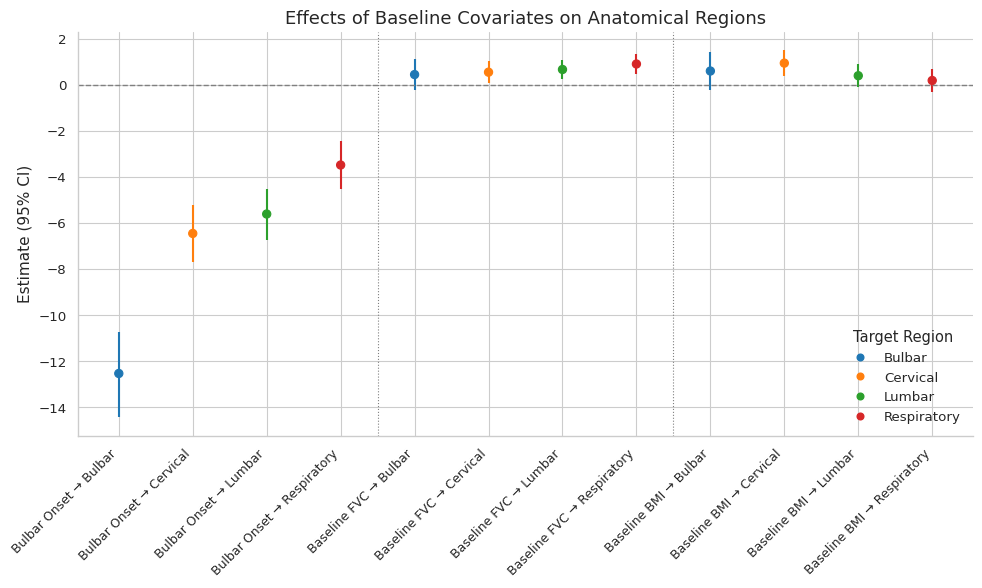

In [43]:
alpha_df = filtered_df[filtered_df["Parameter"].str.contains("alpha")]

# Create DataFrame
df = alpha_df.copy()

# Define labels
i_labels = ["Bulbar", "Cervical", "Lumbar", "Respiratory"]
j_labels = ["Bulbar Onset", "Baseline FVC", "Baseline BMI"]

# Parse the [i, j] parameters
def parse_param(param):
    match = re.match(r"alpha_dyn\[(\d+),(\d+)\]", param)
    if match:
        i = int(match.group(1)) - 1
        j = int(match.group(2)) - 1
        return i, j
    return None, None

df[["i", "j"]] = df["Parameter"].apply(lambda x: pd.Series(parse_param(x)))

# Generate label: j -> i
df["label"] = df.apply(lambda row: f"{j_labels[row['j']]} → {i_labels[row['i']]}", axis=1)

# Sort by j first (to group by baseline covariates), then by i
df = df.sort_values(["j", "i"]).reset_index(drop=True)

# Define coloring scheme by 'i'
color_map = {
    0: "#1f77b4",
    1: "#ff7f0e",
    2: "#2ca02c",
    3: "#d62728"
}
colors = df["i"].map(color_map)

# Initialize plot
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = range(len(df))

# Plot confidence intervals
for x, lo, hi, c in zip(x_pos, df["2.5%"], df["97.5%"], colors):
    ax.vlines(x=x, ymin=lo, ymax=hi, color=c, linewidth=1.5)

# Plot point estimates
ax.scatter(x_pos, df["Estimate"], c=colors, s=35, zorder=3)

# Reference line at 0
ax.axhline(0, color="gray", linestyle="--", linewidth=1)

# Format x-axis ticks
ax.set_xticks(list(x_pos))
ax.set_xticklabels(df["label"], rotation=45, ha="right", fontsize=9)

# Axis labels and title
ax.set_ylabel("Estimate (95% CI)", fontsize=11)
ax.set_title("Effects of Baseline Covariates on Anatomical Regions", fontsize=13)

# Remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add vertical grouping separators (since each j group has 4 values)
for k in range(1, 3):
    ax.axvline(k * 4 - 0.5, color="gray", linestyle=":", linewidth=0.8)

# Add Legend
handles = [
    plt.Line2D([0], [0], marker='o', linestyle='', color=color_map[i], label=i_labels[i])
    for i in range(4)
]
ax.legend(handles=handles, title="Target Region", frameon=False, loc="best")

plt.tight_layout()
save_multiformat("Fig_I_4D_Covariate_Forest_Switched")
print("Generated 'Fig_I_4D_Covariate_Forest_Switched.png' successfully.")

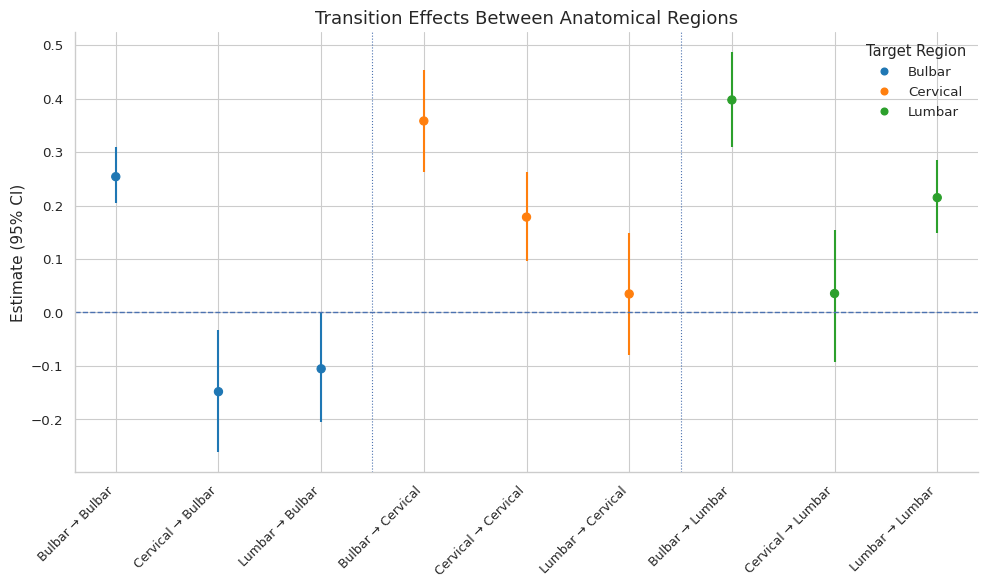

In [44]:
df = pd.read_csv("../raw_results/results_S1_dahlou_ncp_cov_3d_run1.csv")
filtered_df = extract_and_save_parameters(df, output_filename='filtered_mcmc_parameters_3d.csv')
gamma_df = filtered_df[filtered_df["Parameter"].str.contains("Gamma")]

df = gamma_df.copy()

labels = ["Bulbar", "Cervical", "Lumbar"]

def parse_param(param):
    match = re.match(r"Gamma\[(\d+),(\d+)\]", param)
    if match:
        i = int(match.group(1)) - 1
        j = int(match.group(2)) - 1
        return i, j
    return None, None

df[["i", "j"]] = df["Parameter"].apply(lambda x: pd.Series(parse_param(x)))

# j → i
df["label"] = df.apply(lambda row: f"{labels[row['j']]} → {labels[row['i']]}", axis=1)

df = df.sort_values(["i", "j"]).reset_index(drop=True)

color_map = {
    0: "#1f77b4",
    1: "#ff7f0e",
    2: "#2ca02c"
}
colors = df["i"].map(color_map)

# ---- SWITCHED AXES ----
fig, ax = plt.subplots(figsize=(10, 6))  # wider, shorter

x_pos = range(len(df))

# CI (now vertical lines)
for x, lo, hi, c in zip(x_pos, df["2.5%"], df["97.5%"], colors):
    ax.vlines(x=x, ymin=lo, ymax=hi, color=c, linewidth=1.5)

# Points
ax.scatter(x_pos, df["Estimate"], c=colors, s=35, zorder=3)

# Reference line at 0 (now horizontal)
ax.axhline(0, linestyle="--", linewidth=1)

# Labels
ax.set_xticks(list(x_pos))
ax.set_xticklabels(df["label"], rotation=45, ha="right", fontsize=9)

ax.set_ylabel("Estimate (95% CI)", fontsize=11)
ax.set_title("Transition Effects Between Anatomical Regions", fontsize=13)

# Clean look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Group separators (vertical now)
for k in range(1, 3):
    ax.axvline(k*3 - 0.5, linestyle=":", linewidth=0.8)

# Legend
handles = [
    plt.Line2D([0], [0], marker='o', linestyle='', color=color_map[i], label=labels[i])
    for i in range(3)
]
ax.legend(handles=handles, title="Target Region", frameon=False)

plt.tight_layout()
save_multiformat("Fig_I_3D_Interaction_Forest_Switched")

Generated 'Fig_I_3D_Covariate_Forest_Switched.png' successfully.


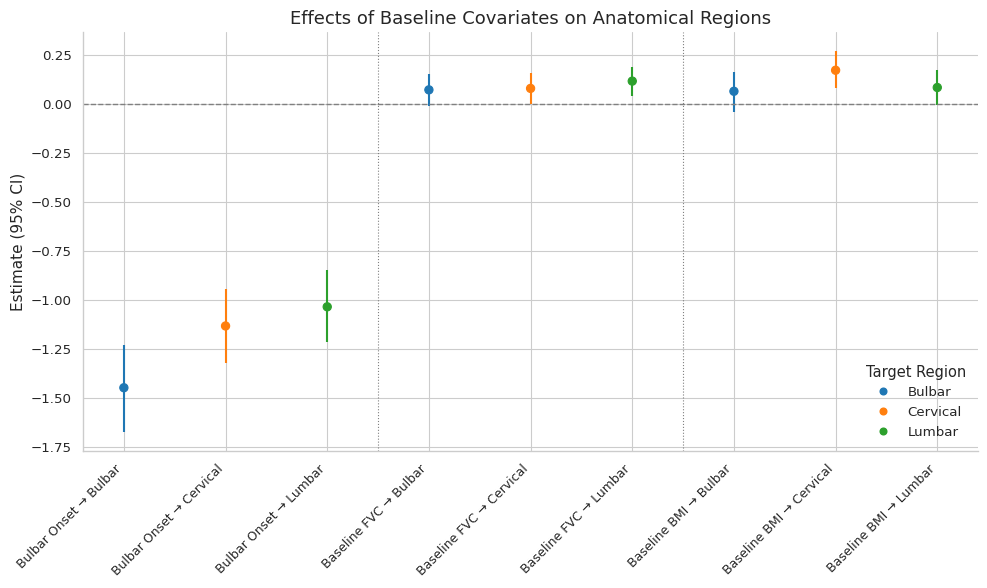

In [45]:
alpha_df = filtered_df[filtered_df["Parameter"].str.contains("alpha")]

# Create DataFrame
df = alpha_df.copy()

# Define labels
i_labels = ["Bulbar", "Cervical", "Lumbar"]
j_labels = ["Bulbar Onset", "Baseline FVC", "Baseline BMI"]

# Parse the [i, j] parameters
def parse_param(param):
    match = re.match(r"alpha_dyn\[(\d+),(\d+)\]", param)
    if match:
        i = int(match.group(1)) - 1
        j = int(match.group(2)) - 1
        return i, j
    return None, None

df[["i", "j"]] = df["Parameter"].apply(lambda x: pd.Series(parse_param(x)))

# Generate label: j -> i
df["label"] = df.apply(lambda row: f"{j_labels[row['j']]} → {i_labels[row['i']]}", axis=1)

# Sort by j first (to group by baseline covariates), then by i
df = df.sort_values(["j", "i"]).reset_index(drop=True)

# Define coloring scheme by 'i'
color_map = {
    0: "#1f77b4",
    1: "#ff7f0e",
    2: "#2ca02c"
}
colors = df["i"].map(color_map)

# Initialize plot
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = range(len(df))

# Plot confidence intervals
for x, lo, hi, c in zip(x_pos, df["2.5%"], df["97.5%"], colors):
    ax.vlines(x=x, ymin=lo, ymax=hi, color=c, linewidth=1.5)

# Plot point estimates
ax.scatter(x_pos, df["Estimate"], c=colors, s=35, zorder=3)

# Reference line at 0
ax.axhline(0, color="gray", linestyle="--", linewidth=1)

# Format x-axis ticks
ax.set_xticks(list(x_pos))
ax.set_xticklabels(df["label"], rotation=45, ha="right", fontsize=9)

# Axis labels and title
ax.set_ylabel("Estimate (95% CI)", fontsize=11)
ax.set_title("Effects of Baseline Covariates on Anatomical Regions", fontsize=13)

# Remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add vertical grouping separators (since each j group has 4 values)
for k in range(1, 3):
    ax.axvline(k * 3 - 0.5, color="gray", linestyle=":", linewidth=0.8)

# Add Legend
handles = [
    plt.Line2D([0], [0], marker='o', linestyle='', color=color_map[i], label=i_labels[i])
    for i in range(3)
]
ax.legend(handles=handles, title="Target Region", frameon=False, loc="best")

plt.tight_layout()
save_multiformat("Fig_I_3D_Covariate_Forest_Switched")
print("Generated 'Fig_I_3D_Covariate_Forest_Switched.png' successfully.")